In [1]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy
from kneed import KneeLocator
from typing import Tuple, Literal, Any
import scipy.stats as stats
from gensim.models import KeyedVectors
import re
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib as mpl
from cycler import cycler


In [2]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', '#3EB489', '#6B8E23'])

In [3]:
df = pd.read_csv('/home/uplong/Downloads/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)
df.dtypes

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1
1,A,2018-01-01,0,BURN,1,0
2,A,2018-01-01,0,SHAKING,1,1
3,A,2018-01-01,0,VOMITING,1,0
4,A,2018-01-01,1,FROSTBITE,1,0
...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0
1174307,D,2025-08-31,23,DIZZINESS,1,0
1174308,D,2025-08-31,23,FINGER PAIN,1,0


Site                         object
Date                 datetime64[ns]
Hour                          int32
REASON_VISIT_NAME            object
ED Enc                        int64
ED Enc Admitted               int64
dtype: object

In [4]:
display(df.isna().sum())

Site                    0
Date                    0
Hour                    0
REASON_VISIT_NAME    6205
ED Enc                  0
ED Enc Admitted         0
dtype: int64

In [5]:
df.describe()

,Date,Hour,ED Enc,ED Enc Admitted
count,1174310,1.174310e+06,1.174310e+06,1.174310e+06
mean,2021-12-05 23:13:59.314321664,1.354932e+01,1.084646e+00,2.915218e-01
min,2018-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2019-12-23 00:00:00,1.000000e+01,1.000000e+00,0.000000e+00
50%,2021-12-30 00:00:00,1.400000e+01,1.000000e+00,0.000000e+00
75%,2023-11-11 00:00:00,1.900000e+01,1.000000e+00,1.000000e+00
max,2025-08-31 00:00:00,2.300000e+01,8.000000e+00,5.000000e+00
std,NaN,6.142173e+00,3.228135e-01,4.772703e-01


In [109]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # overall admission rate

np.float64(0.26877133038813356)

In [94]:
# Minor preprossesing that will be useful for later
df.fillna('NaN', inplace=True)

def _remove_special_characters(text:str) -> str:
    return re.sub(r"[^a-zA-Z0-9 ]", "  ", text)

def _replace_covid(text:str) -> str:
    return re.sub('COVID', 'CORONOVIRUS', text)

df['REASON_VISIT_NAME'] = df['REASON_VISIT_NAME'].apply(_remove_special_characters).apply(_replace_covid)

## Reason of encounter analysis

In [8]:
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons.sort()
unique_reasons, unique_reasons.shape

(array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
        'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN',
        'ABN FOLLOW  UP', 'ABNORMAL CT', 'ABNORMAL CXR', 'ABNORMAL EEG',
        'ABNORMAL ELECTROCARDIOGRAM   ECG     EKG  ', 'ABNORMAL G TUBE',
        'ABNORMAL HEART SCREEN', 'ABNORMAL LABS', 'ABNORMAL PET SCAN',
        'ABRASION', 'ABSCESS', 'ABSTRACT', 'ACCESSORY NIPPLE',
        'ACUTE RENAL FAILURE', 'ADDICTION PROBLEM', 'ADDISONS DISEASE',
        'ADENOPATHY', 'ADJUSTMENT ISSUES', 'ADRENAL CANCER',
        'ADVANCE CARE PLANNING', 'AGGRESSIVE BEHAVIOR', 'AGITATION',
        'AICD PROBLEM', 'AIRWAY OBSTRUCTION', 'ALCOHOL INTOXICATION',
        'ALCOHOL PROBLEM', 'ALLERGIC REACTION', 'ALLERGIC RHINITIS',
        'ALLERGIES', 'ALLIED HEALTH VISIT', 'ALOPECIA',
        'ALS   AMYOTROPHIC LATERAL SCLEROSIS  ', 'ALTERED MENTAL STATUS',
        'AMENORRHEA', 'AMPUTATION', 'ANAL FISSURE', 'ANAL FISTUAL',
        'ANAL ITCHING', 'ANEMIA', 'ANEMIA MANAGEMENT

In [9]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admittance'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


In [10]:
COVID_df = reason_count[(reason_count['percentage_of_admittance']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)

<Axes: xlabel='REASON_VISIT_NAME'>

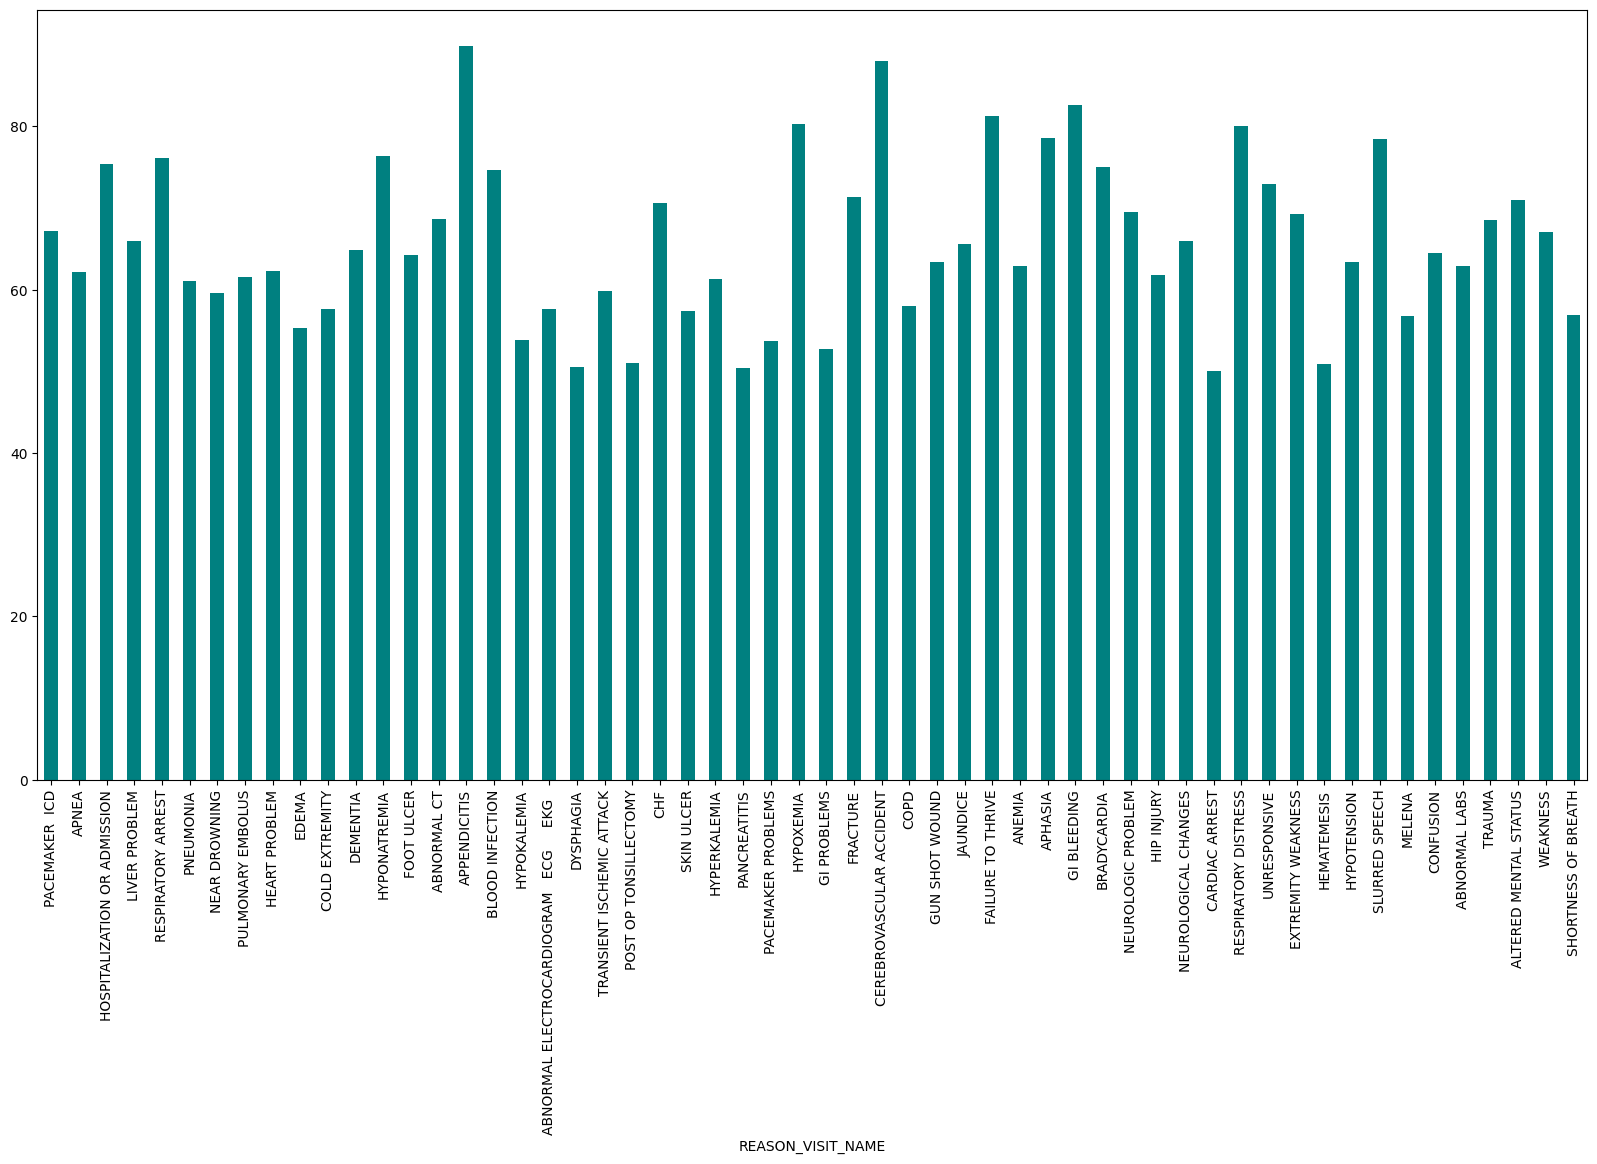

In [11]:
COVID_df['percentage_of_admittance'].plot(kind='bar', figsize=(20,10))

## Date/Time analysis

<Axes: xlabel='Year'>

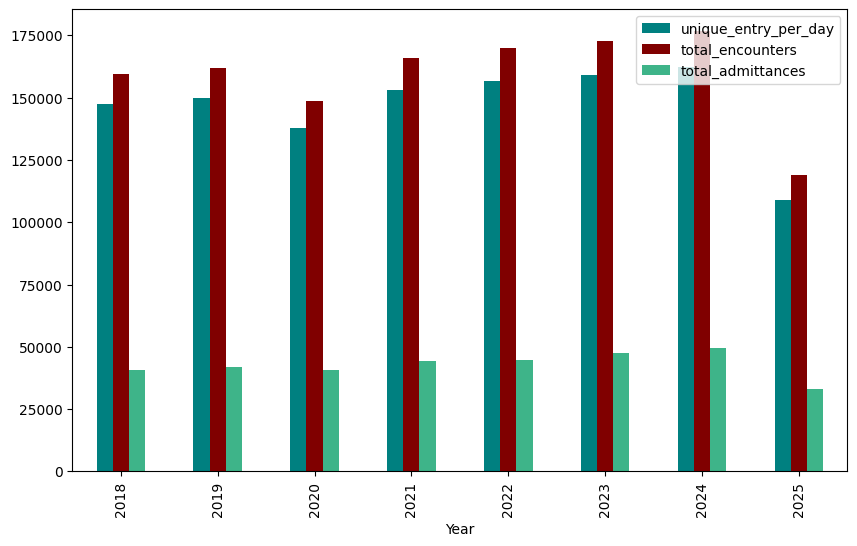

In [12]:
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(10,6), xlabel='Year')

In [13]:
# Check what happend in Covid peak
df[(df['Date'].dt.year == 2020) & (df['Date'].dt.month >= 3) & (df['Date'].dt.month <= 6)].groupby(by='REASON_VISIT_NAME').agg('size').sort_values(ascending=False)

REASON_VISIT_NAME
ABDOMINAL PAIN              3490
CHEST PAIN                  2524
SHORTNESS OF BREATH         1667
FALL                        1539
FEVER                       1222
                            ... 
TRACHEOSTOMY TUBE CHANGE       1
ABNORMAL EEG                   1
WORD FINDING PROBLEMS          1
WOUND VAC PLACEMENT            1
ABNORMAL G TUBE                1
Length: 530, dtype: int64

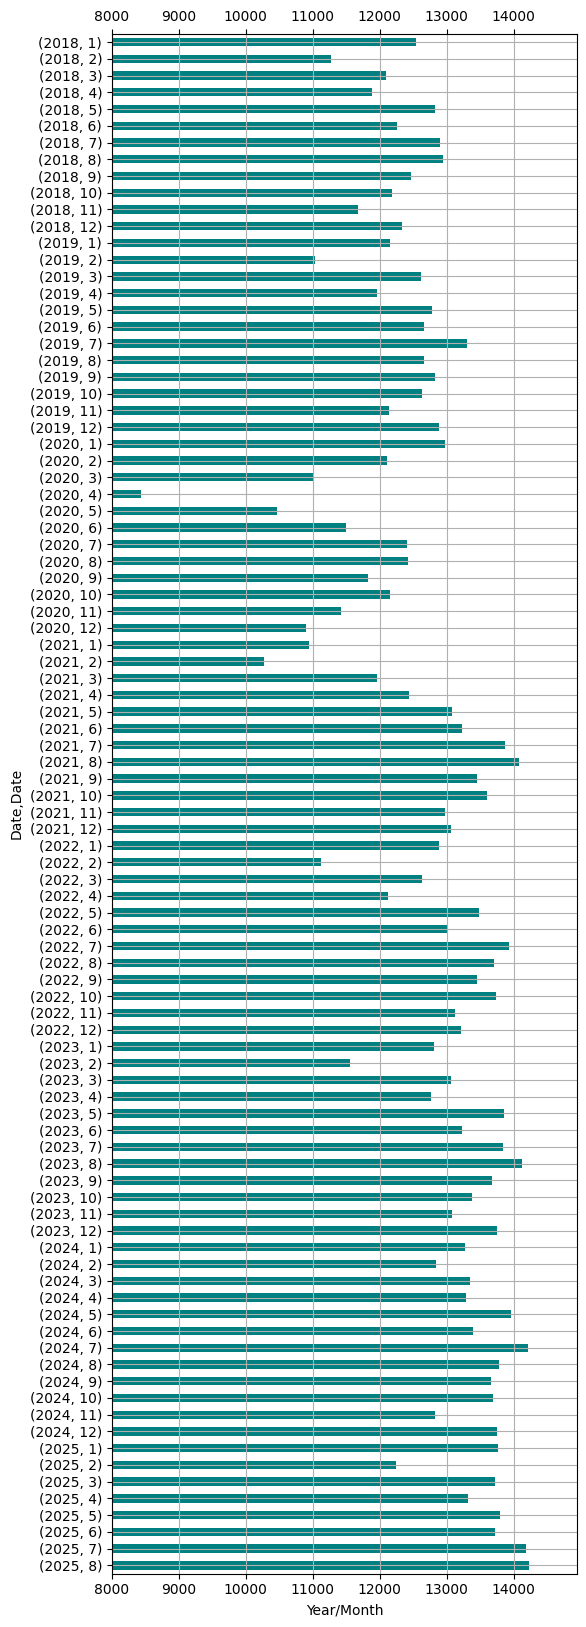

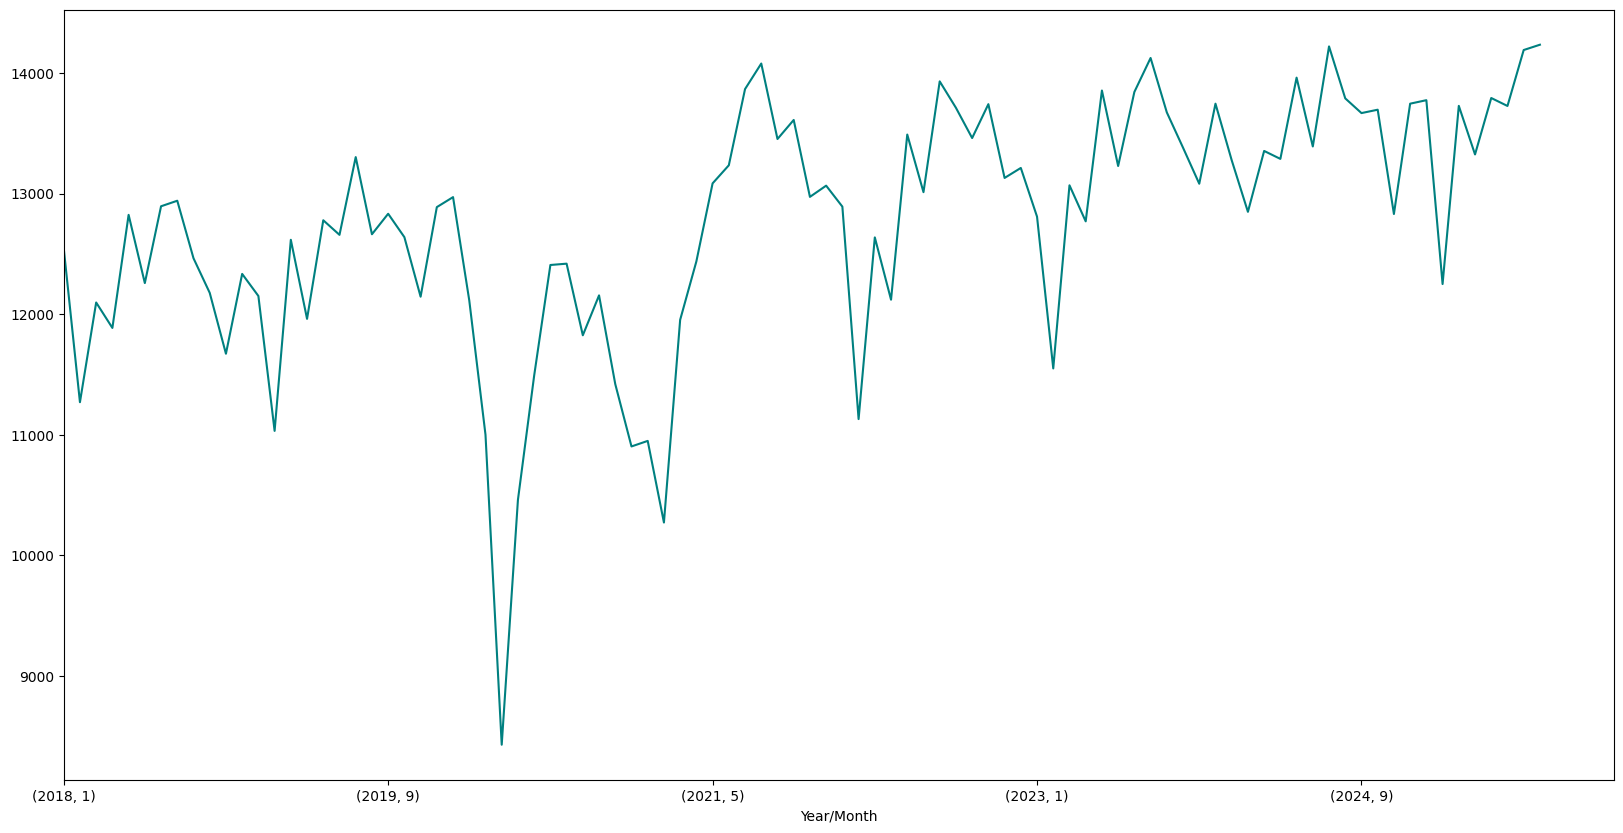

In [14]:
grouped_by_year_month = df.groupby(by = [df['Date'].dt.year, df['Date'].dt.month]).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (6,20), xlabel='Year/Month', xlim=8000, grid=True)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (20,10), xlabel='Year/Month', xlim=0)
plt.show()



<Axes: xlabel='Month'>

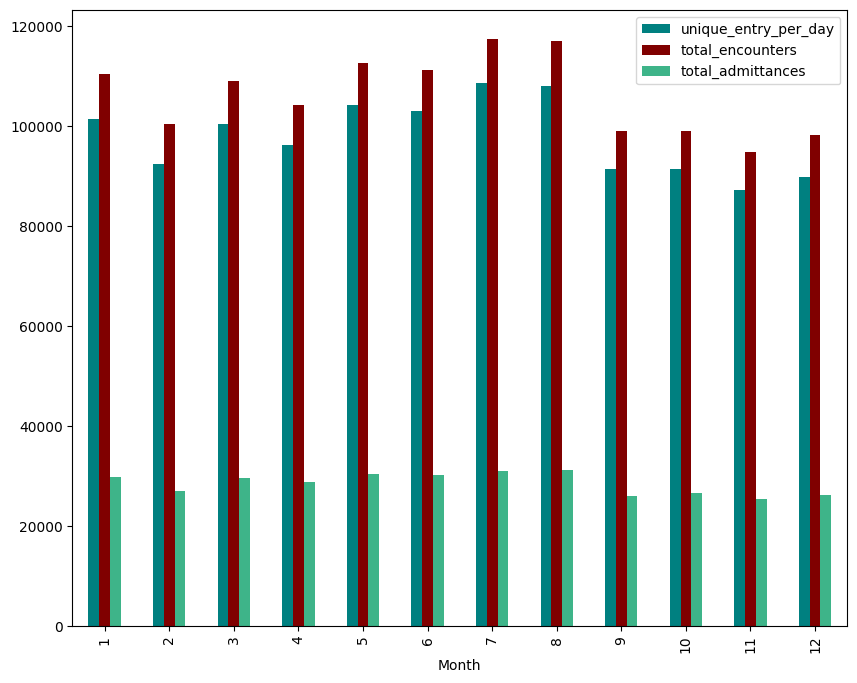

In [15]:
grouped_by_month = df.groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_month.plot(kind='bar', figsize = (10,8), xlabel='Month')

<Axes: xlabel='Day of the month'>

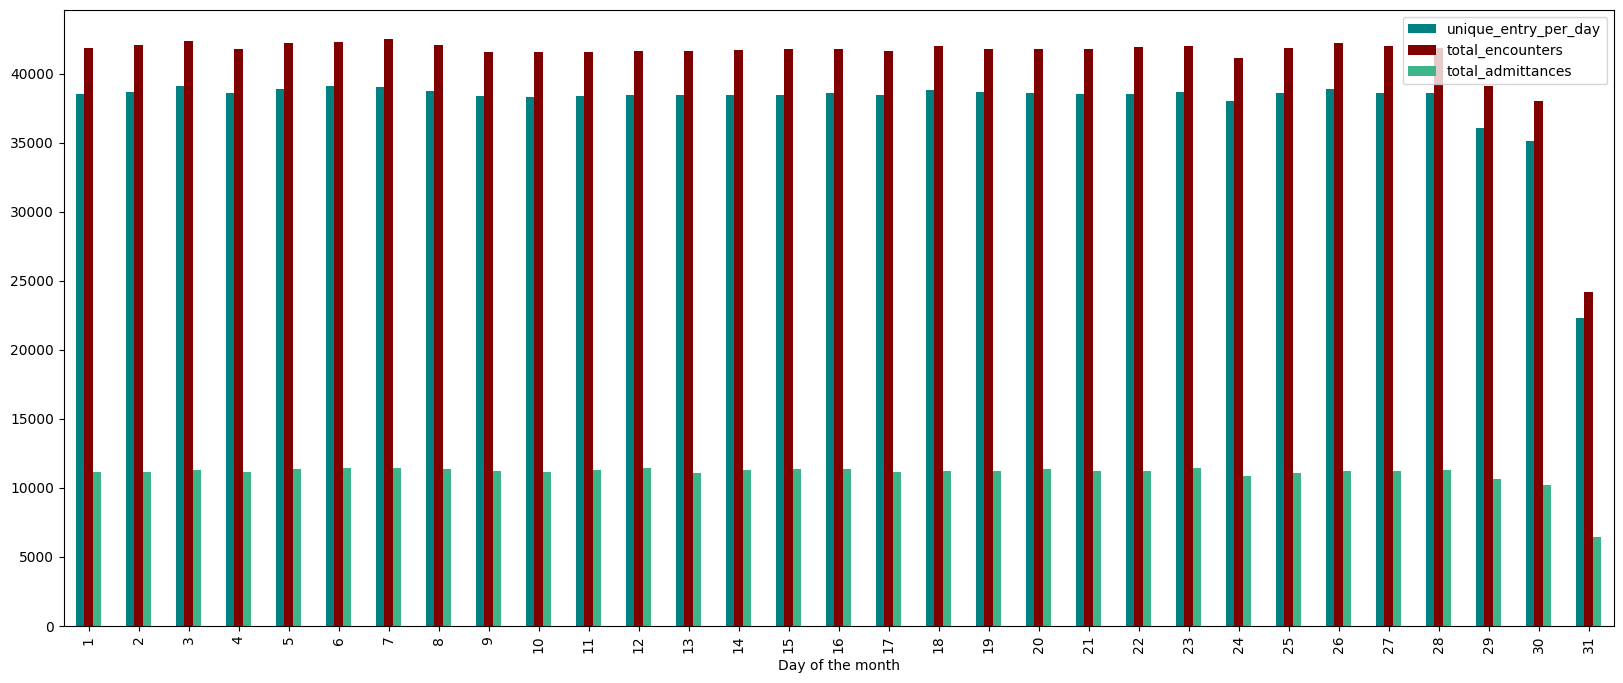

In [16]:
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day.plot(kind='bar', figsize = (20,8), xlabel='Day of the month')

<Axes: xlabel='Day of the week'>

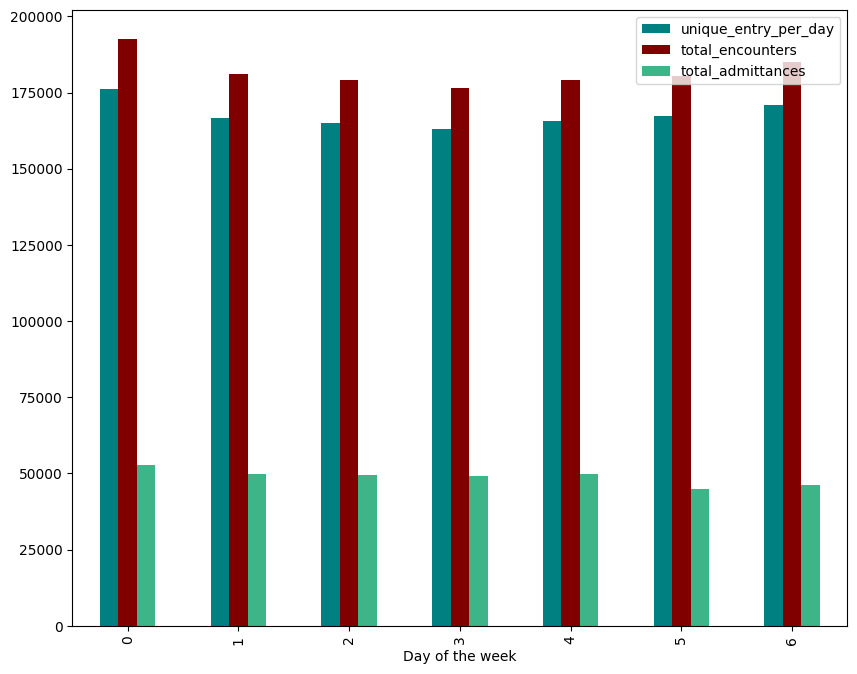

In [17]:
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week.plot(kind='bar', figsize = (10,8), xlabel='Day of the week')

In [18]:
grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
        grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
)

,Date,REASON_VISIT_NAME,0
4,2018,ABDOMINAL PAIN,12184
18,2018,ALCOHOL INTOXICATION,1625
20,2018,ALLERGIC REACTION,799
23,2018,ALTERED MENTAL STATUS,1063
34,2018,ANKLE INJURY,879
...,...,...,...
5169,2025,VAGINAL BLEEDING,918
5181,2025,VOMITING,2701
5183,2025,WEAKNESS,1895
5189,2025,WITHDRAWAL,536


,Date,REASON_VISIT_NAME,0
20,2018,ALLERGIC REACTION,799
692,2019,ALLERGIC REACTION,902
1352,2020,ALLERGIC REACTION,665
1996,2021,ALLERGIC REACTION,905
2659,2022,ALLERGIC REACTION,889
3339,2023,ALLERGIC REACTION,969
3996,2024,ALLERGIC REACTION,1072
4634,2025,ALLERGIC REACTION,700


Since there is no much insight in direct date analysis, lets try to see if there are any "seasonal illnesses"

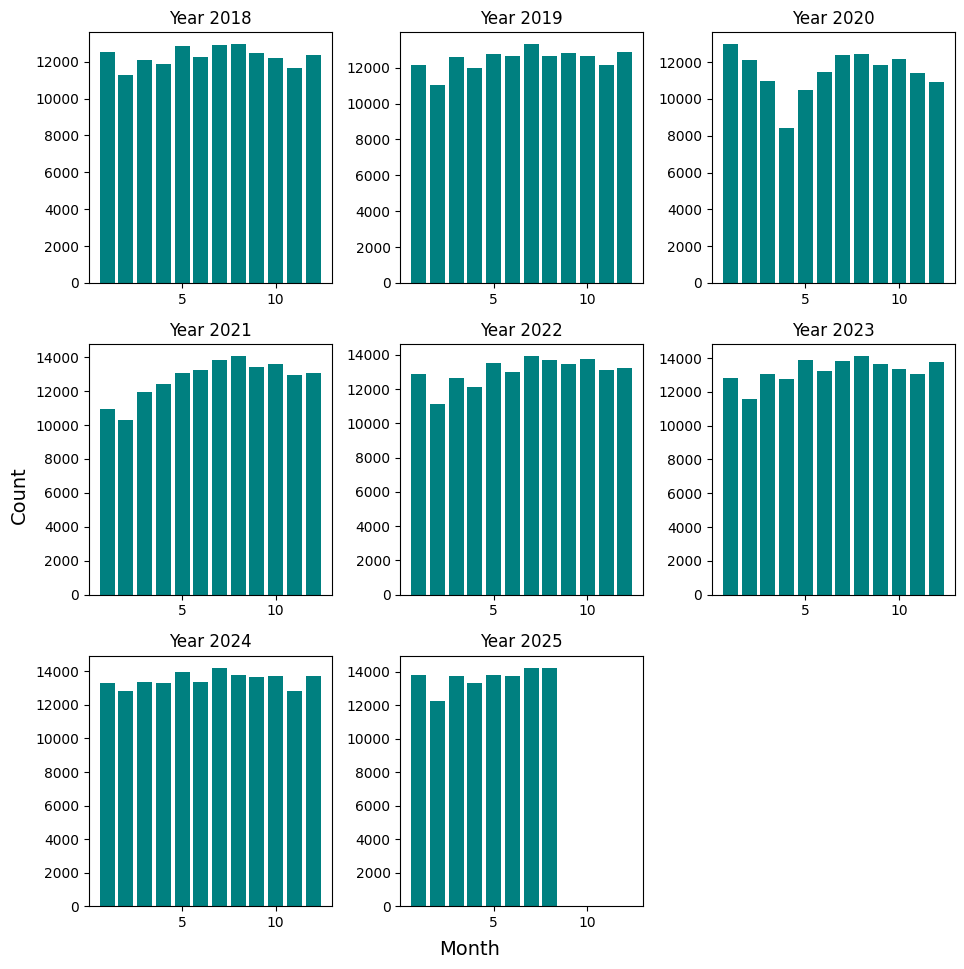

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))  
axes = axes.flatten() 

years = range(2018, 2026) 

for idx, j in enumerate(years):
    df_year = df[df['Date'].dt.year == j]
    test = df_year.groupby([df_year['Date'].dt.month, df_year['REASON_VISIT_NAME']]).size()

    count_of_reasons_per_month = [test.loc[i].sum() if i in test.index.levels[0] else 0 for i in range(1, 13)]

    axes[idx].bar(range(1, 13), count_of_reasons_per_month)
    axes[idx].set_title(f"Year {j}")
    # axes[idx].set_xlabel("Month")
    # axes[idx].set_ylabel("Count")

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Count', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


In [20]:
test = df[df['Date'].dt.year==2022].groupby(by=[df['Date'].dt.month, df['REASON_VISIT_NAME']])['REASON_VISIT_NAME'].apply('size').to_frame()
test2 = test.rename(columns={'REASON_VISIT_NAME':'count_of_reason'}).reset_index()
test2[test2['count_of_reason']>500]

,Date,REASON_VISIT_NAME,count_of_reason
3,1,ABDOMINAL PAIN,1014
75,1,CHEST PAIN,788
343,1,SHORTNESS OF BREATH,537
421,2,ABDOMINAL PAIN,952
487,2,CHEST PAIN,698
825,3,ABDOMINAL PAIN,1084
892,3,CHEST PAIN,729
969,3,FALL,504
1238,4,ABDOMINAL PAIN,973
1310,4,CHEST PAIN,752


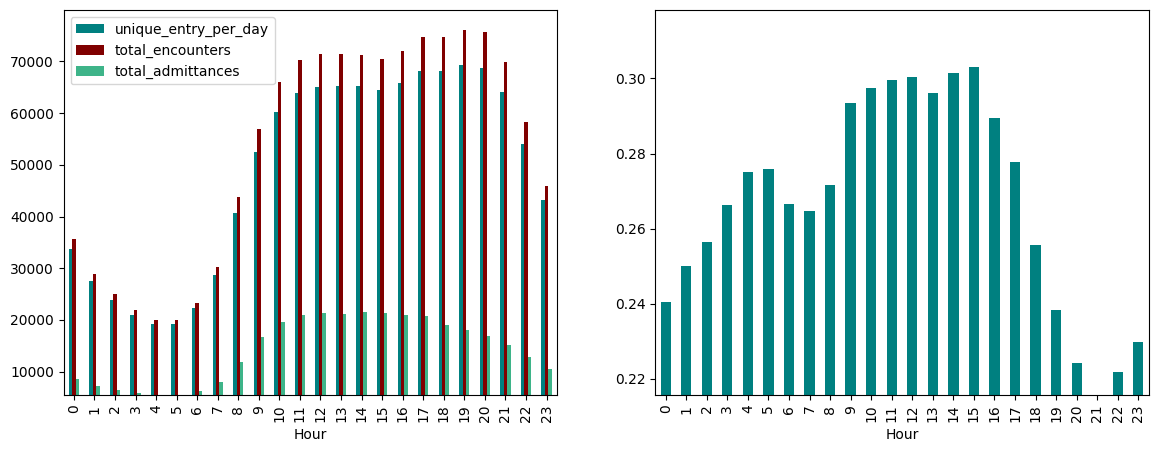

In [21]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_time.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'], ax=axes[0])
grouped_by_time['admitance_rate'].plot(kind='bar', ylim=grouped_by_time['admitance_rate'].min(), ax=axes[1])
plt.show()


## Analysis by site

,site,total_encounters,total_admittances,admittance_rate
Site,,,,
A,308478,339622,107210,0.315674
B,423139,463877,118092,0.254576
C,250370,267847,81899,0.305768
D,192323,202365,35136,0.173627


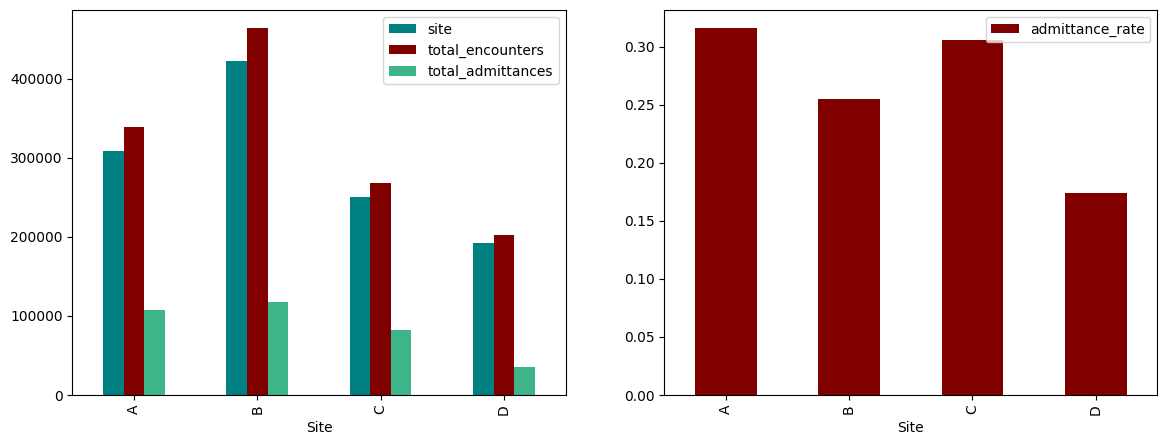

In [22]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_site.iloc[:,:-1].plot(kind='bar', ax=axes[0]) # finally some sort of imbalance
grouped_by_site['admittance_rate'].plot(kind='bar', ax=axes[1], legend=True, color='maroon')
plt.show()

## Misc

Why would 'ED Enc' and 'ED Enc Admitted' take values > 1 ?

In [23]:
df[df['ED Enc']>1].shape[0] / df.shape[0] # only 7%

0.07344312830513237

In [24]:
df[df['ED Enc Admitted']>1].shape[0] / df.shape[0]

0.00950856247498531

# Syndromic Grouping & Clustering

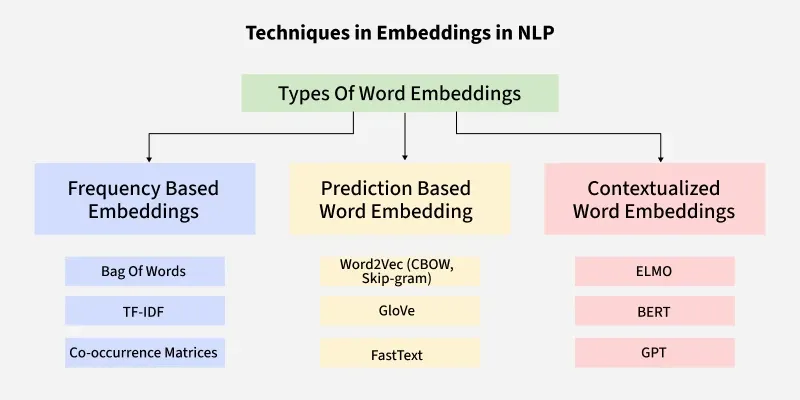

* Vectorizers used so far: TF-IDF, W2V
* Clustering algorithms used so far: K-Means, BisectingKMeans

* Note, up to discussion: should we cluster based on semantic or textual similarity? If we want semantic we need to normalize, to make the Euclidean distance equivalent to the cosine similarity (which is done a toggle is put in the basic function).

## TF-IDF

In [25]:
unique_reasons

array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
       'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN',
       'ABN FOLLOW  UP', 'ABNORMAL CT', 'ABNORMAL CXR', 'ABNORMAL EEG',
       'ABNORMAL ELECTROCARDIOGRAM   ECG     EKG  ', 'ABNORMAL G TUBE',
       'ABNORMAL HEART SCREEN', 'ABNORMAL LABS', 'ABNORMAL PET SCAN',
       'ABRASION', 'ABSCESS', 'ABSTRACT', 'ACCESSORY NIPPLE',
       'ACUTE RENAL FAILURE', 'ADDICTION PROBLEM', 'ADDISONS DISEASE',
       'ADENOPATHY', 'ADJUSTMENT ISSUES', 'ADRENAL CANCER',
       'ADVANCE CARE PLANNING', 'AGGRESSIVE BEHAVIOR', 'AGITATION',
       'AICD PROBLEM', 'AIRWAY OBSTRUCTION', 'ALCOHOL INTOXICATION',
       'ALCOHOL PROBLEM', 'ALLERGIC REACTION', 'ALLERGIC RHINITIS',
       'ALLERGIES', 'ALLIED HEALTH VISIT', 'ALOPECIA',
       'ALS   AMYOTROPHIC LATERAL SCLEROSIS  ', 'ALTERED MENTAL STATUS',
       'AMENORRHEA', 'AMPUTATION', 'ANAL FISSURE', 'ANAL FISTUAL',
       'ANAL ITCHING', 'ANEMIA', 'ANEMIA MANAGEMENT', 'ANEURYSM', 

In [26]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=False)

X = vectorizer.fit_transform(unique_reasons) # return a sparse matrix where row -> reason, column -> embedding vector
vectorizer.get_feature_names_out().tolist()[:15]

['19',
 '19 EXPOSURE',
 '19 INFORMATION',
 '19 OUTPATIENT',
 'ABDOMINAL',
 'ABDOMINAL AORTIC',
 'ABDOMINAL CRAMPING',
 'ABDOMINAL DISTENTION',
 'ABDOMINAL INJURY',
 'ABDOMINAL PAIN',
 'ABN',
 'ABN FOLLOW',
 'ABNORMAL',
 'ABNORMAL CT',
 'ABNORMAL CXR']

In [27]:
X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()

(array([113]),)

In [28]:
unique_reasons[X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()]

array(['BREATHING PROBLEM'], dtype=object)

In [29]:
idxs_of_keyword = X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()
idxs_of_keyword

(array([113]),)

In [30]:
vectorizer.vocabulary_['BREATHING PROBLEM']

201

In [31]:
unique_reasons_containing_keyword = unique_reasons[X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()]
unique_reasons_containing_keyword

array(['BREATHING PROBLEM'], dtype=object)

## BioWordVec
https://github.com/ncbi-nlp/BioSentVec?tab=readme-ov-file#biowordvec

In [32]:
# MODEL_PATH = "BioWordVec_PubMed_MIMICIII_d200.vec.bin"

# bwv = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True, limit=int(3e6))

In [33]:
# def sentence_vector(text: str) -> np.ndarray:
#     tokens = text.lower().split()
#     vectors = [bwv[word] for word in tokens if word in bwv]

#     if not vectors:
#         # return np.zeros(200, dtype=np.float32)
#         return 0

#     return np.mean(vectors, axis=0)

# embeddings = np.vstack([sentence_vector(t) for t in unique_reasons])
# print(embeddings.shape)

In [34]:
# np.sum(embeddings == np.zeros(200))

In [35]:
# # Sanity check: we are not missing any words from the model, which is due to preprocessing

# l=[]
# for r in unique_reasons:
#     tokens = r.lower().split()
#     check = l.extend([word for word in tokens if word not in bwv.key_to_index])

# l


In [36]:
# X.shape, embeddings.shape

##### Basic Vectorization function

In [37]:
def _sentence_vector(text: str, v: KeyedVectors) -> np.ndarray:
    tokens = text.lower().split()
    vectors = [v[word] for word in tokens if word in v]

    if not vectors:
        return np.zeros(200, dtype=np.float32)

    return np.mean(vectors, axis=0)

def _normalize(embeddings:np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings_normalized = embeddings / np.clip(norms, a_min=1e-12, a_max=None)
    return embeddings_normalized

def vectorize(data : np.ndarray, vectorizer : Literal['tf_idf', 'bio_word_vec'] = 'tf_idf', normalize:bool = False) -> Any:
    if vectorizer == 'tf_idf':
        v_ = TfidfVectorizer(ngram_range=(1,2), lowercase=False)
        embeddings = v_.fit_transform(data).toarray()
        return embeddings if not normalize else _normalize(embeddings)
    elif vectorizer == 'bio_word_vec':
        v_ = KeyedVectors.load_word2vec_format('BioWordVec_PubMed_MIMICIII_d200.vec.bin', binary=True, limit=int(3e6)) 
        embeddings = np.vstack([_sentence_vector(t, v_) for t in unique_reasons])
        return embeddings if not normalize else _normalize(embeddings)

## K-Means

In [38]:
# Data for tf-idf 
e_t = vectorize(data=unique_reasons, vectorizer='tf_idf', normalize=True)

# Data for w2v
e_w = vectorize(data=unique_reasons, vectorizer='bio_word_vec', normalize=True)

In [39]:
# model = KMeans(n_clusters=17, random_state=1) 
# model_weighted = KMeans(n_clusters=6, random_state=1) 
# model_w2v = KMeans(n_clusters=20, random_state=1)
# model_w2v_weighted = KMeans(n_clusters=5, random_state=1)


# pred_cluster = model.fit_predict(X) # UNWEIGHTED 
# pred_cluster_weighted = model_weighted.fit_predict(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 
# pred_cluster_w2v = model_w2v.fit_predict(embeddings) # UNWEIGHTED 
# pred_cluster_weighted_w2v = model_w2v_weighted.fit_predict(embeddings, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 

In [40]:
# pred_cluster[idxs_of_keyword], pred_cluster_weighted[idxs_of_keyword] # We see that if the keyward cancer is included then they are all clustered together

In [41]:
# pred_cluster_w2v[idxs_of_keyword], pred_cluster_weighted_w2v[idxs_of_keyword]

In [42]:
# unique_reasons_containing_keyword[np.where(pred_cluster[idxs_of_keyword]!=4)]

##### Basic model function

In [43]:
def kmeans_model(
        n_clusters:int,
        data:np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
) -> np.ndarray:
    m = KMeans(n_clusters=n_clusters, random_state=random_state)
    if weighted:
        pc = m.fit(data) 
    else:
        pc = m.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())  
    
    return pc

### Optimization of numbers of clusters

https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d

https://medium.com/@jeffzyme/understanding-inertia-distortion-and-silhouette-scores-and-their-differences-key-metrics-for-458fe28ce2aa

Three "standard" measures for analysis of clustering algorithms:
* **Inertia:** Measures the compactness of the clusters i.e. how close the points of each cluster is to their respective centroid. 
$$\text{INERTIA} =\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert^2$$
It’s particularly useful in the Elbow Method when combined with distortion.

* **Distortion:** Lower distortion scores suggest points are tightly grouped, but too many clusters may imply overfitting. 
$$\text{Distortion Score} = \frac{1}{N}\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert$$

* **Silhouette:** High average silhouette scores across all points suggest strong clustering, with distinct separation between clusters. This score is particularly insightful for comparing different clustering approaches, as it evaluates both within-cluster tightness and inter-cluster separation. For $x\in C$
$$\text{Silhouette Score}=\frac{b-a}{\max(a,b)}$$
 where $a$ is the average distance of $x$ to every other point in its cluster and $b$ is the average from all the points to the neighboring cluster (i.e. the cluster with the closer centroid).

The overall Silhouette Score is the average of silhouette scores for all points, producing a range from −1 to 1:

*    Values close to 1 indicate well-separated clusters,
*    Values near 0 suggest overlapping clusters,
*    Negative values signal possible misclassification.

In [108]:
def distortion_score(model: KMeans | BisectingKMeans, X: np.ndarray | scipy.sparse._csr.csr_matrix) -> float:
    labels = model.labels_
    centers = model.cluster_centers_
    N = X.shape[0]
    ds = 1/N * np.linalg.norm((X.toarray() - centers[labels])) if type(X) == scipy.sparse._csr.csr_matrix else 1/N * np.linalg.norm((X - centers[labels]))
    return ds

def find_elbow(
        clusters_upper_bound:int,
        data: np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
        model_type:str = Literal['kmeans', 'bkmeans'],
) -> int:
    
    ks = range(2, clusters_upper_bound, 1)
    inertias = []
    distortions = []
    silhouettes = []

    for k in ks:
        if model_type =='kmeans':
            model = KMeans(n_clusters=k, random_state=random_state)
        elif model_type =='bkmeans':
            model = BisectingKMeans(n_clusters=k, random_state=random_state)        
        if weighted:
            model.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
        else:
            model.fit(data)

        inertias.append(model.inertia_)
        distortions.append(distortion_score(model, data))
        silhouettes.append( silhouette_score(data, model.predict(data)) )

    kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Inertia
    axes[0].plot(ks, inertias, '-o', color='blue')
    axes[0].set_title('Inertia')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inertia')

    # Distortion
    axes[1].plot(ks, distortions, '-o', color='red')
    axes[1].set_title('Distortion')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('Distortion')

    # Silhouette
    axes[2].plot(ks, silhouettes, '-o', color='green')
    axes[2].set_title('Silhouette Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Score')

    # Knee lines (only where meaningful)
    for ax in axes:
        for k in kn.all_knees:
            ax.axvline(k, linestyle='--', color='black')

    plt.tight_layout()
    plt.show()

    return kn.knee

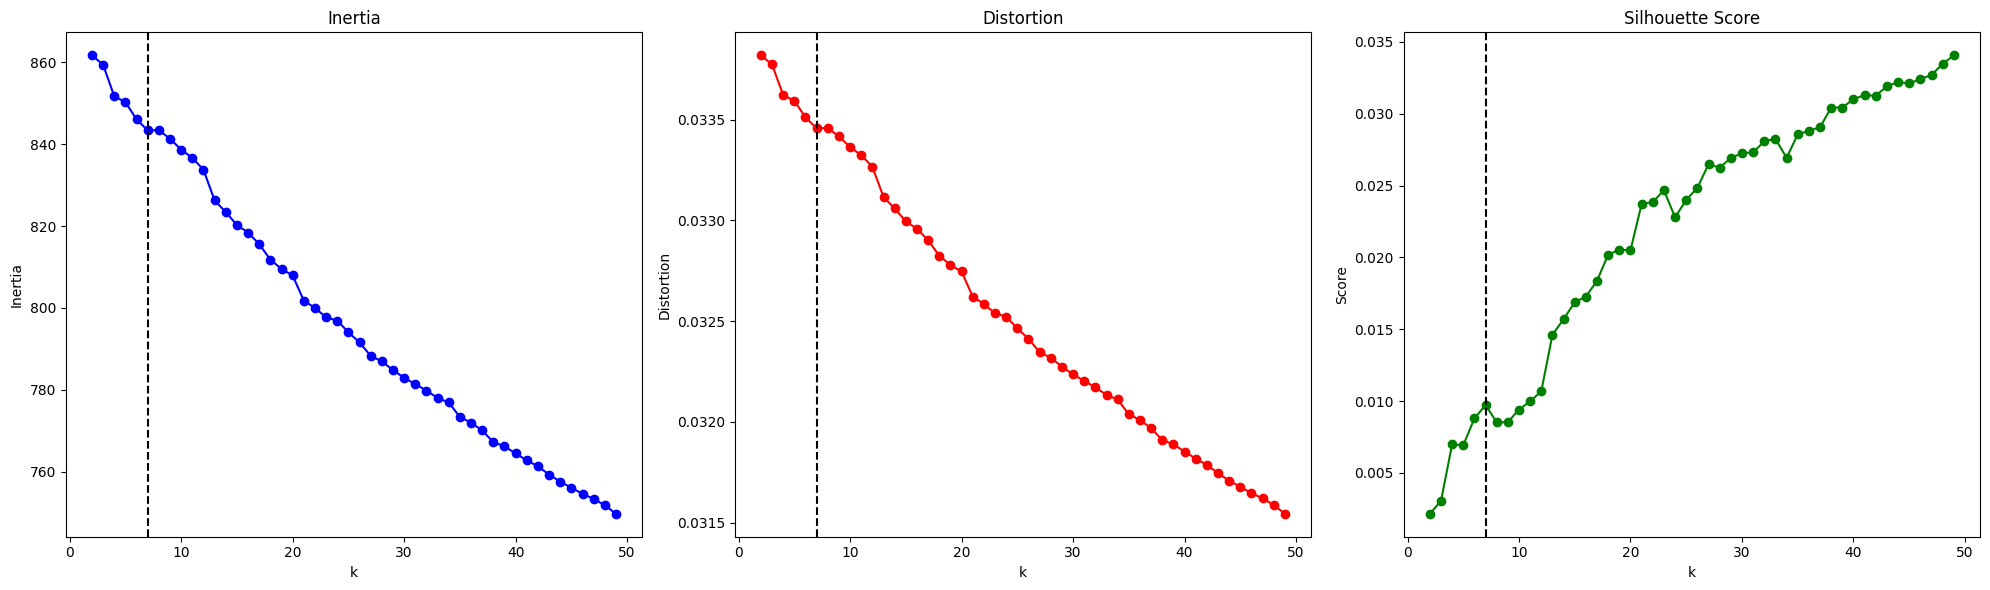

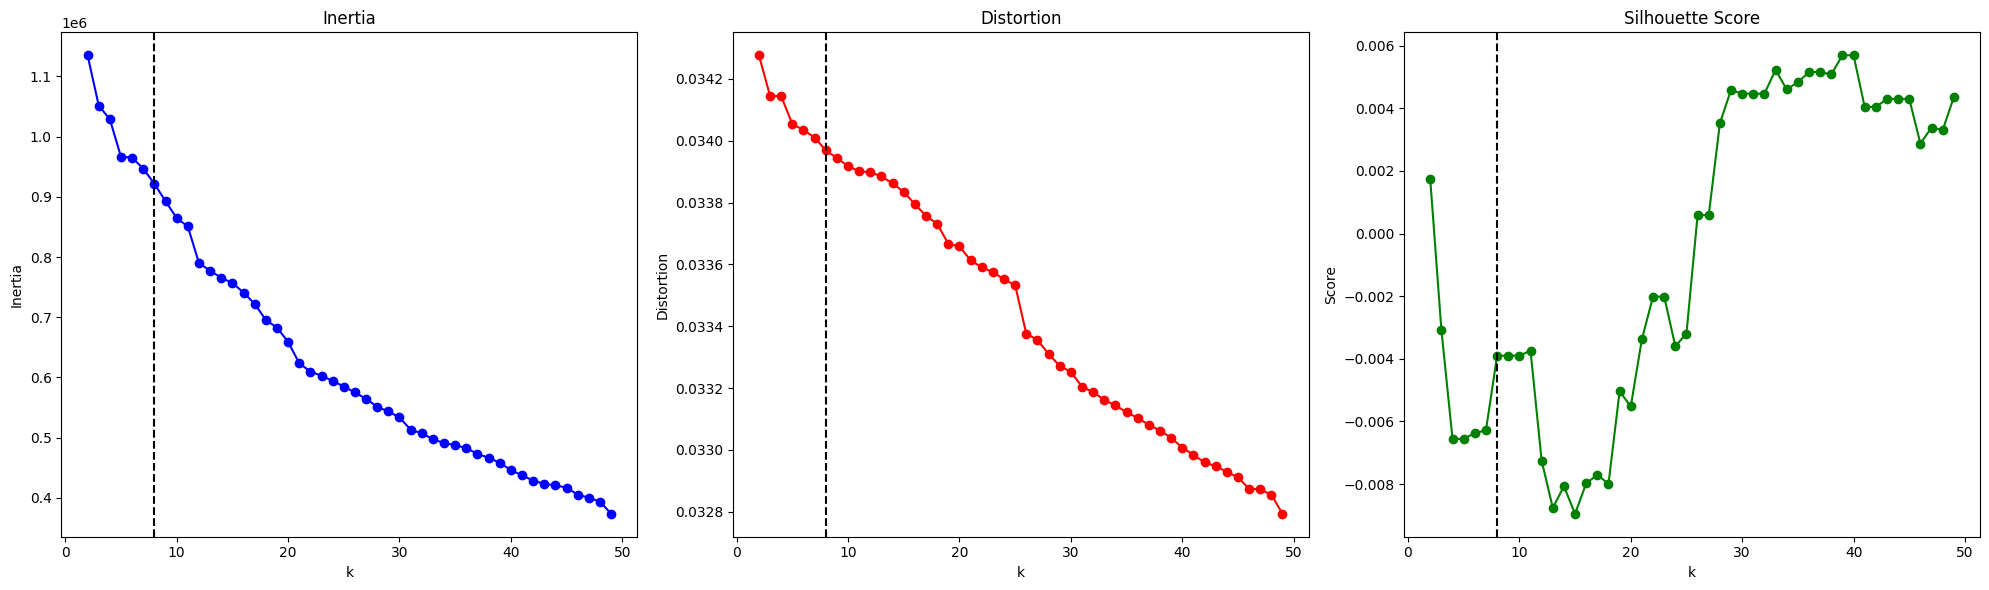

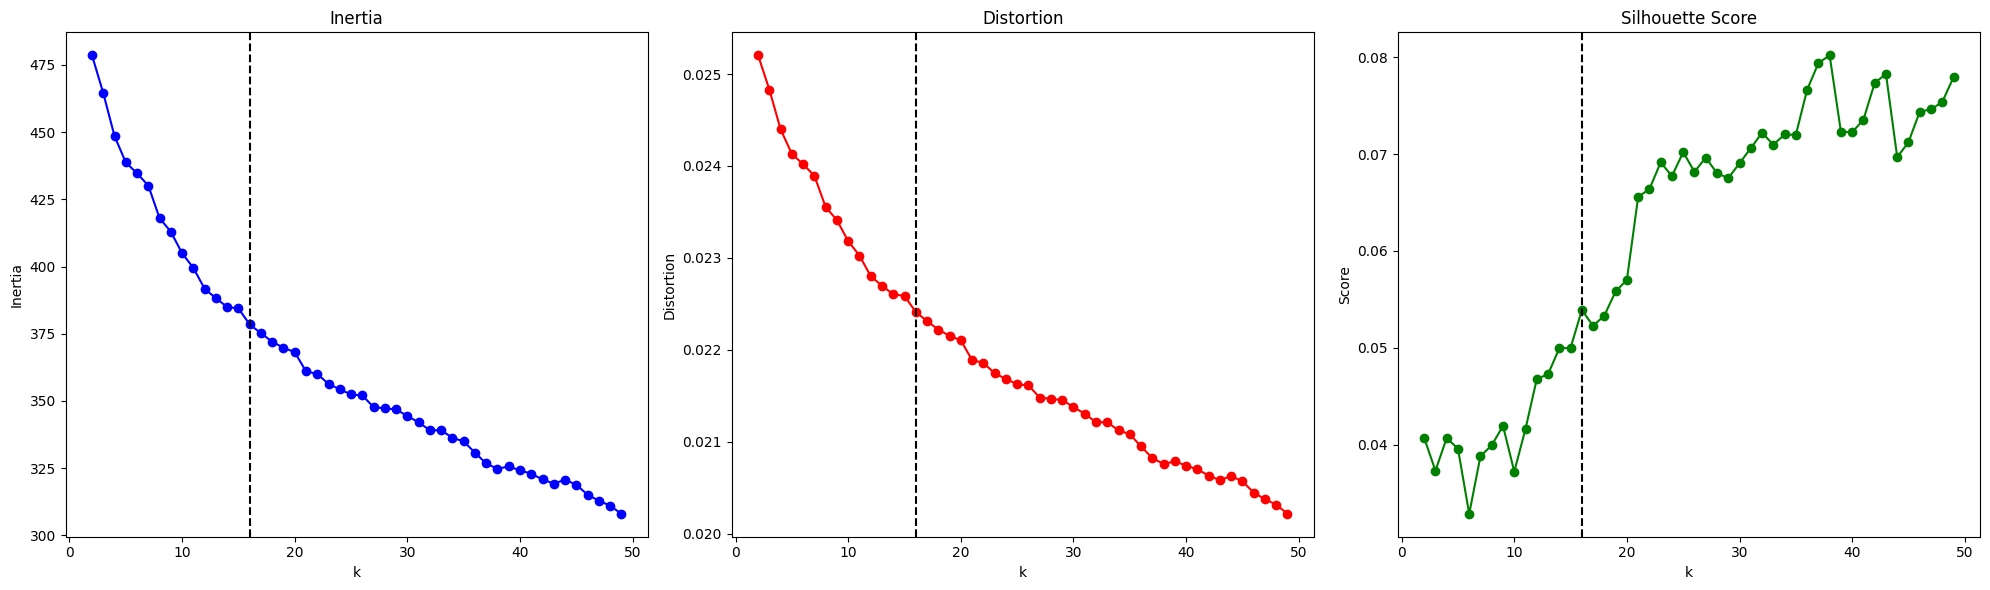

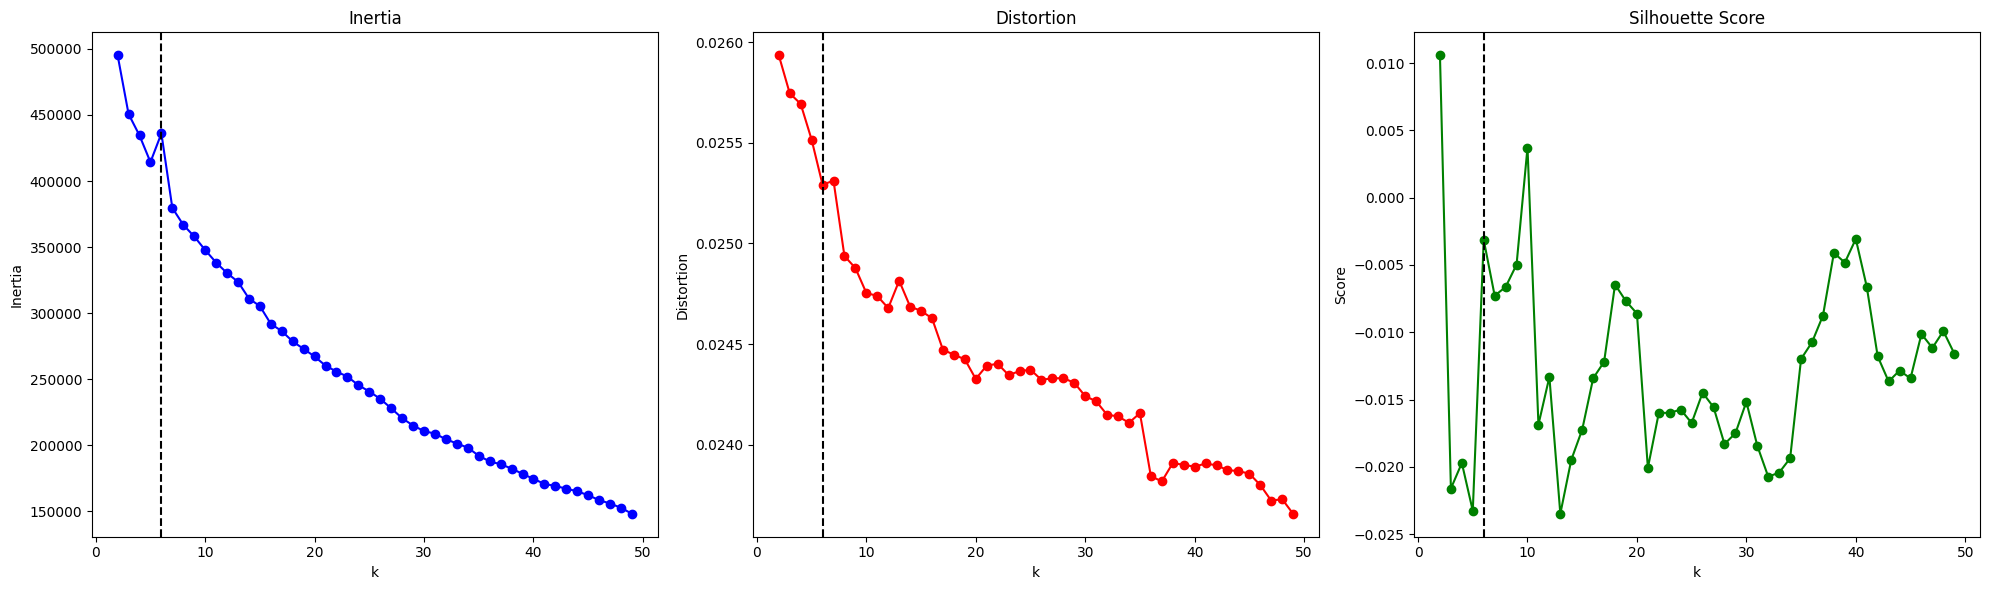

In [46]:
# Optimal number of clusters for unweighted, tf-idf, kmeans model
k1 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='kmeans')

# Optimal number of clusters for weighted, tf-idf, kmeans model
k2 = find_elbow(clusters_upper_bound=50, data=e_t, weighted=True, model_type='kmeans')

# Optimal number of cluster for unweighted, w2v, kmeans model
k3 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='kmeans')

# Optimal number of cluster for weighted, w2v, kmeans model
k4 = find_elbow(clusters_upper_bound=50, data=e_w, weighted=True, model_type='kmeans')

In [47]:
k1, k2, k3, k4

(np.int64(7), np.int64(8), np.int64(16), np.int64(6))

In [48]:
# # Opt. for unweighted K-Means with TF-IDF

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:
#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(X)
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, X))
#     silhouettes.append( silhouette_score(X, model.predict(X)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [49]:
# kn.knee

In [50]:
# # Opt. for weighted K-Means with TF-IDF

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:

#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, X))
#     silhouettes.append( silhouette_score(X, model.predict(X)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [51]:
# kn.all_knees

In [52]:
# # Opt. for unweighted K-Means with w2v

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:

#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(embeddings)
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, embeddings))
#     silhouettes.append( silhouette_score(embeddings, model.predict(embeddings)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [53]:
# kn.knee

In [54]:
# find_elbow(50, embeddings, True, 1)

In [55]:
# # Opt. for weighted K-Means with w2v

# ks = range(2, 50)
# inertias = []
# distortions = []
# silhouettes = []

# weights = reason_count.sort_index()['total_occurences_of_reason'].to_numpy()

# for k in ks:
#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(embeddings, sample_weight=weights)

#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, embeddings))
#     silhouettes.append(silhouette_score(embeddings, model.labels_))

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()


In [56]:
# kn.all_knees

### Qualitative analysis on the cluster-optimized K-means model.

In [57]:
# Models 

# Unweighted, tf-idf, kmeans
m1 = kmeans_model(n_clusters=k1, data=e_t)

# Weighted, tf-idf, kmeans
m2 = kmeans_model(n_clusters=k2, data=e_t, weighted=True)

# Unweighted, w2v, kmeans
m3 = kmeans_model(n_clusters=k3, data=e_w)

# Weighted, w2v, kmeans
m4 = kmeans_model(n_clusters=k4, data=e_w, weighted=True)

In [58]:
def remap(reason:str, model, data: np.ndarray) -> int:
    '''
    Input:
        str - the reason of the encounter 
    Output:
        Tuple[int, int] - the corresponding cluster of the unweighted and weighted models respectively
    '''
    idx_of_reason = np.where(reason == unique_reasons)
    return model.predict(data[idx_of_reason])[0]

# remap('ABDOMINAL PAIN', model=model, model_weighted=model_weighted)


In [59]:
unique_vals = df["REASON_VISIT_NAME"].unique()
unique_vals

array(['BREATHING PROBLEM', 'BURN', 'SHAKING', 'VOMITING', 'FROSTBITE',
       'SEIZURES', 'ANXIETY', 'FEVER', 'COPD', 'LACERATION', 'FALL',
       'SYNCOPE', 'ABDOMINAL PAIN', 'NEAR SYNCOPE', 'SHORTNESS OF BREATH',
       'DRUG OVERDOSE', 'URINARY BURNING', 'DERM PROBLEM',
       'NASAL CONGESTION', 'COUGH', 'LEG PAIN', 'SORE THROAT',
       'SURGICAL FOLLOWUP', 'WEAKNESS', 'BACK PAIN', 'FLANK PAIN',
       'FOOT PAIN', 'HEADACHE', 'KNEE PAIN', 'ARM PAIN', 'CELLULITIS',
       'CHEST PAIN', 'EVALUATION OF SEXUAL ASSAULT', 'CLOSED HEAD INJURY',
       'FLU  LIKE SYMPTOMS', 'HAND PAIN', 'NaN', 'NAUSEA',
       'ASSAULT VICTIM', 'COLD EXPOSURE', 'RECTAL PAIN', 'RECTAL PROBLEM',
       'BLOOD PRESSURE', 'EAR INFECTION', 'HEMATEMESIS', 'OTHER',
       'RESPIRATORY DISTRESS', 'ANKLE PAIN', 'FOOT INJURY', 'DIZZINESS',
       'FACIAL INJURY', 'HIGH BLOOD SUGAR', 'MEDICATION REQUEST',
       'MOTOR VEHICLE CRASH', 'SWELLING', 'RASH', 'RIB PAIN',
       'SHOULDER PAIN', 'NECK PAIN', 'DIARRHEA',

In [60]:
# Include the clustering to the df
unique_vals = df["REASON_VISIT_NAME"].unique()

r1 = {val: remap(val, m1, e_t) for val in unique_vals}
r2 = {val: remap(val, m2, e_t) for val in unique_vals}
r3 = {val: remap(val, m3, e_w) for val in unique_vals}
r4 = {val: remap(val, m4, e_w) for val in unique_vals}

df["td-idf"] = df["REASON_VISIT_NAME"].map(r1)
df["weighted_td-idf"] = df["REASON_VISIT_NAME"].map(r2)
df["w2v"] = df["REASON_VISIT_NAME"].map(r3)
df["w2v_weighted"] = df["REASON_VISIT_NAME"].map(r4)

In [61]:
df

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,td-idf,weighted_td-idf,w2v,w2v_weighted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1,3,2,15,0
1,A,2018-01-01,0,BURN,1,0,2,2,13,2
2,A,2018-01-01,0,SHAKING,1,1,2,2,0,3
3,A,2018-01-01,0,VOMITING,1,0,2,2,4,3
4,A,2018-01-01,1,FROSTBITE,1,0,2,2,13,2
...,...,...,...,...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,7,13,2
1174306,D,2025-08-31,23,CHEST PAIN,1,0,4,2,3,5
1174307,D,2025-08-31,23,DIZZINESS,1,0,2,2,6,3
1174308,D,2025-08-31,23,FINGER PAIN,1,0,2,2,8,5


In [62]:
grouped_by_UM_clusters = df.groupby(by='td-idf').agg('size')
grouped_by_WM_clusters = df.groupby(by='weighted_td-idf').agg('size')
grouped_by_UM_w2v_clusters = df.groupby(by='w2v').agg('size')
grouped_by_WM_w2v_clusters = df.groupby(by='w2v_weighted').agg('size')


In [63]:
display(grouped_by_UM_clusters.describe())
display(grouped_by_WM_clusters.describe())
display(grouped_by_UM_w2v_clusters.describe())
display(grouped_by_WM_w2v_clusters.describe())

count         7.000000
mean     167758.571429
std      343530.456318
min        1114.000000
25%       11559.500000
50%       44203.000000
75%       81476.000000
max      942922.000000
dtype: float64

count    8.000000e+00
mean     1.467888e+05
std      3.862051e+05
min      2.000000e+00
25%      7.400000e+01
50%      1.772500e+03
75%      2.308425e+04
max      1.101356e+06
dtype: float64

count        16.000000
mean      73394.375000
std       38252.072151
min       11900.000000
25%       50306.000000
50%       69879.500000
75%       84739.250000
max      145010.000000
dtype: float64

count         6.000000
mean     195718.333333
std      137011.499972
min       16501.000000
25%       96145.500000
50%      199674.500000
75%      311056.000000
max      348641.000000
dtype: float64

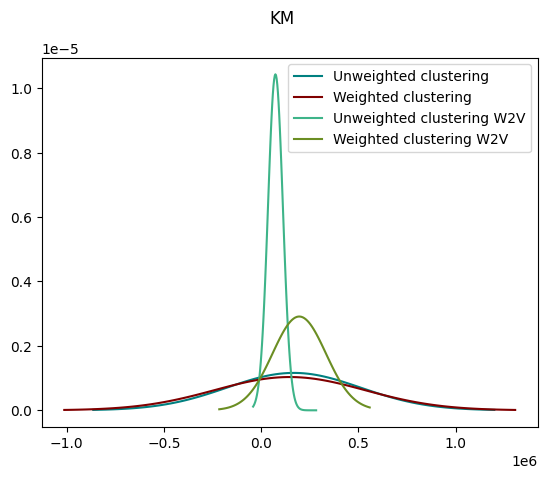

In [64]:
mu1 = grouped_by_UM_clusters.mean()
sigma1 = grouped_by_UM_clusters.std()
variance1 = sigma1 ** 2

mu2 = grouped_by_WM_clusters.mean()
sigma2 = grouped_by_WM_clusters.std()
variance2 = sigma2 ** 2

mu3 = grouped_by_UM_w2v_clusters.mean()
sigma3 = grouped_by_UM_w2v_clusters.std()
variance1 = sigma3 ** 2

mu4 = grouped_by_WM_w2v_clusters.mean()
sigma4 = grouped_by_WM_w2v_clusters.std()
variance4 = sigma4 ** 2

x1 = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 100)
x2 = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 100)
x3 = np.linspace(mu3 - 3*sigma3, mu1 + 3*sigma3, 100)
x4 = np.linspace(mu4 - 3*sigma4, mu2 + 3*sigma4, 100)

plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Unweighted clustering')
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Weighted clustering')
plt.plot(x3, stats.norm.pdf(x3, mu3, sigma3), label='Unweighted clustering W2V')
plt.plot(x4, stats.norm.pdf(x4, mu4, sigma4), label='Weighted clustering W2V')
plt.suptitle('KM')
plt.legend()
plt.show()

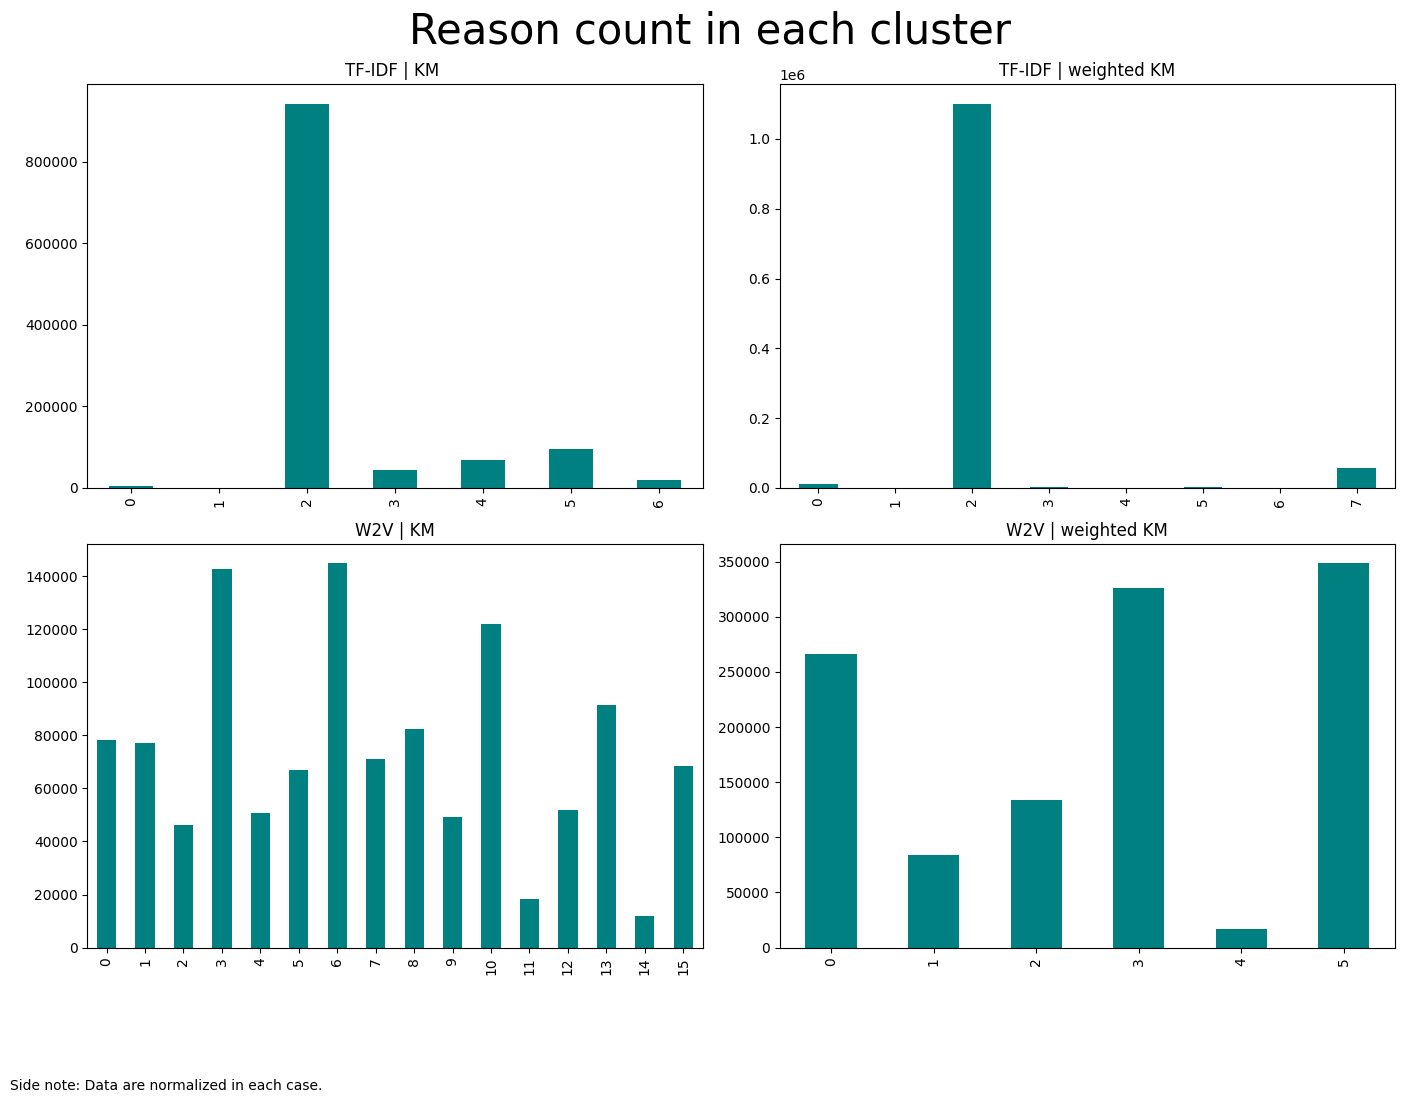

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters.plot(kind='bar', ax=axes[0,0], title='TF-IDF | KM ', xlabel='')
grouped_by_WM_clusters.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted KM', xlabel='')

grouped_by_UM_w2v_clusters.plot(kind='bar', ax=axes[1,0], title='W2V | KM', xlabel='')
grouped_by_WM_w2v_clusters.plot(kind='bar', ax=axes[1,1], title='W2V | weighted KM', xlabel='')

fig.suptitle('Reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()

In [66]:
grouped_by_UM_clusters_unique_reasons = df.groupby(by=['td-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_clusters_unique_reasons['count'] = grouped_by_UM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_clusters_unique_reasons

,REASON_VISIT_NAME,count
td-idf,,
0,"[CORONOVIRUS 19 INFORMATION, CORONOVIRUS 19 EX...",4
1,[ABDOMINAL DISTENTION],1
2,"[BURN, SHAKING, VOMITING, FROSTBITE, SEIZURES,...",857
3,"[BREATHING PROBLEM, DERM PROBLEM, EYE PROBLEM]",3
4,[CHEST PAIN],1
5,[ABDOMINAL PAIN],1
6,[FLANK PAIN],1


In [67]:
grouped_by_WM_clusters_unique_reasons = df.groupby(by=['weighted_td-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_clusters_unique_reasons['count'] = grouped_by_WM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_clusters_unique_reasons

,REASON_VISIT_NAME,count
weighted_td-idf,,
0,"[NASAL CONGESTION, FOREIGN BODY IN NOSE, FOREI...",15
1,"[DIABETIC FOOT CARE, PALLIATIVE CARE REFERRAL,...",10
2,"[BREATHING PROBLEM, BURN, SHAKING, VOMITING, F...",782
3,"[LOSS OF VISION, HEARING LOSS, WEIGHT LOSS, LO...",8
4,"[LUNG CANCER, CANCER, RECTAL CANCER, COLON CAN...",15
5,"[CARDIAC ARREST, CARDIAC DEVICE EVALUATION, RE...",6
6,[VASECTOMY],1
7,"[CLOSED HEAD INJURY, FOOT INJURY, FACIAL INJUR...",31


In [68]:
grouped_by_UM_w2v_clusters_unique_reasons = df.groupby(by=['w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_w2v_clusters_unique_reasons['count'] = grouped_by_UM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
w2v,,
0,"[SHAKING, URINARY BURNING, NASAL CONGESTION, F...",173
1,"[LACERATION, SURGICAL FOLLOWUP, CELLULITIS, SW...",130
2,[FALL],1
3,"[SORE THROAT, BACK PAIN, CHEST PAIN, RIB PAIN,...",20
4,"[VOMITING, NAUSEA, HEMATEMESIS, MELENA, EMESIS...",12
5,"[SHORTNESS OF BREATH, COUGH, RESPIRATORY DISTR...",8
6,"[ANXIETY, SYNCOPE, NEAR SYNCOPE, WEAKNESS, HEA...",68
7,"[COPD, EVALUATION OF SEXUAL ASSAULT, OTHER, ME...",215
8,"[LEG PAIN, FOOT PAIN, KNEE PAIN, ARM PAIN, HAN...",36


In [69]:
grouped_by_WM_w2v_clusters_unique_reasons = df.groupby(by=['w2v_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_w2v_clusters_unique_reasons['count'] = grouped_by_WM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
w2v_weighted,,
0,"[BREATHING PROBLEM, FALL, DRUG OVERDOSE, DERM ...",244
1,"[URINARY BURNING, NASAL CONGESTION, SORE THROA...",151
2,"[BURN, FROSTBITE, LACERATION, CLOSED HEAD INJU...",88
3,"[SHAKING, VOMITING, SEIZURES, ANXIETY, FEVER, ...",147
4,"[COPD, HYPERTENSION, MISCARRIAGE, ASTHMA, GOUT...",117
5,"[ABDOMINAL PAIN, LEG PAIN, SURGICAL FOLLOWUP, ...",121


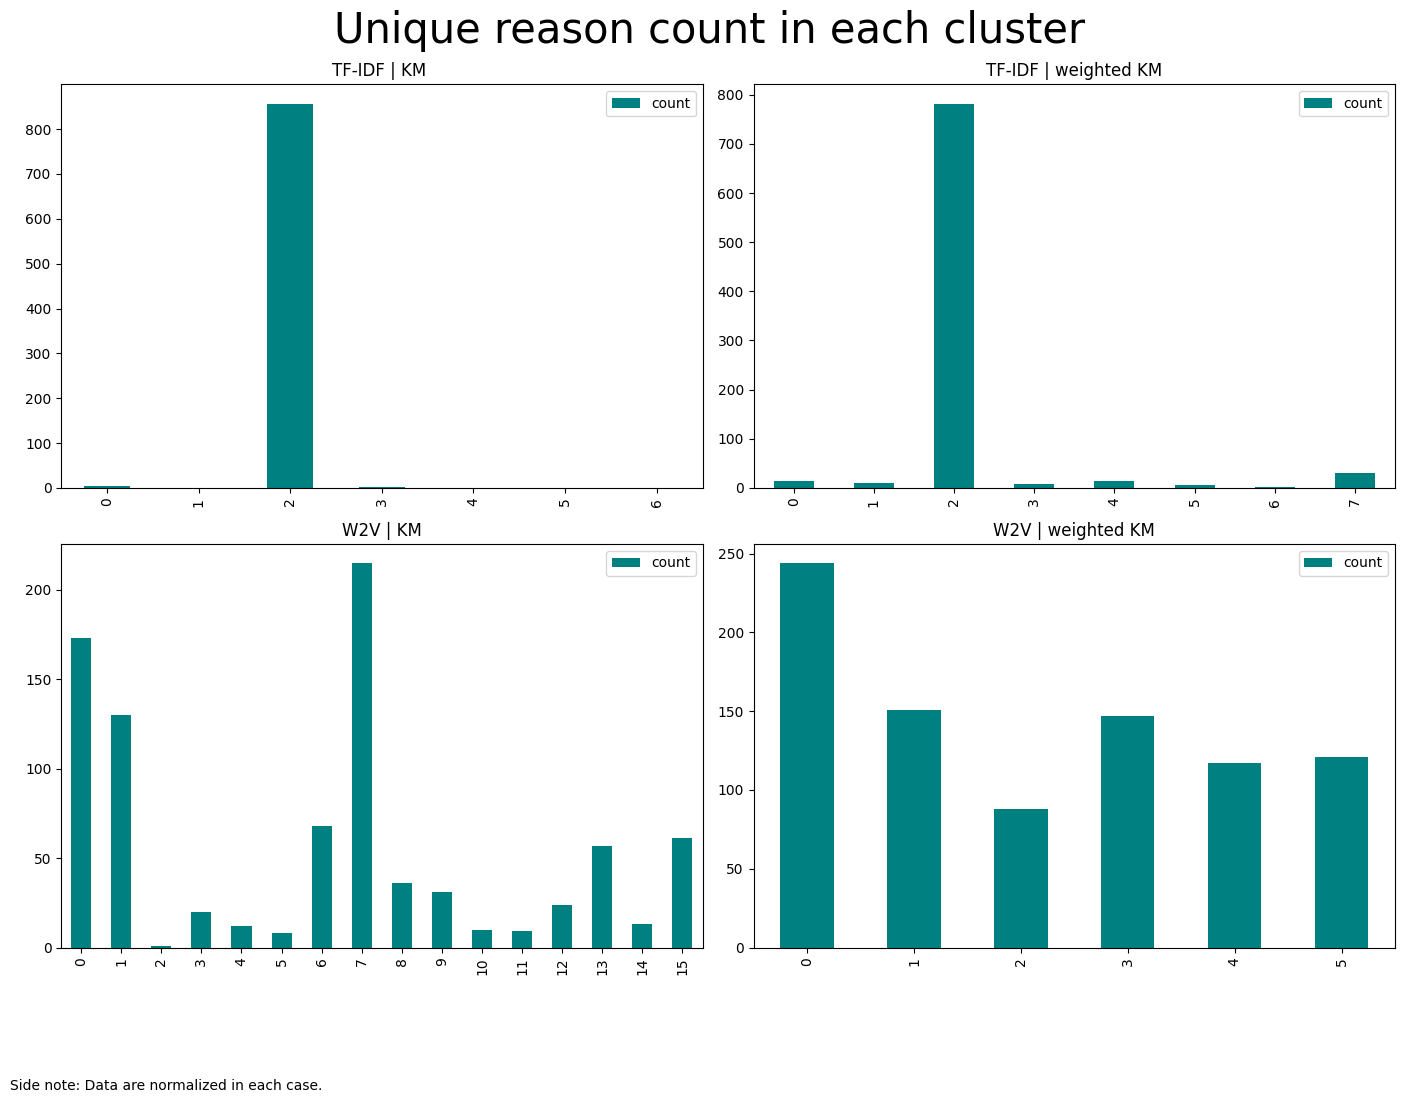

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,0], title='TF-IDF | KM ', xlabel='')
grouped_by_WM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted KM', xlabel='')

grouped_by_UM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,0], title='W2V | KM', xlabel='')
grouped_by_WM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,1], title='W2V | weighted KM', xlabel='')

fig.suptitle('Unique reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()

In [71]:
# grouped_by_UM_w2v_clusters_unique_reasons.to_csv('grouped_by_UM_w2v_clusters_unique_reasons')

## Bisecting K-means

In [72]:
def bkmeans_model(
        n_clusters:int,
        data:np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
) -> np.ndarray:
    m = BisectingKMeans(n_clusters=n_clusters, random_state=random_state)
    if weighted:
        pc = m.fit(data) 
    else:
        pc = m.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())  
    
    return pc

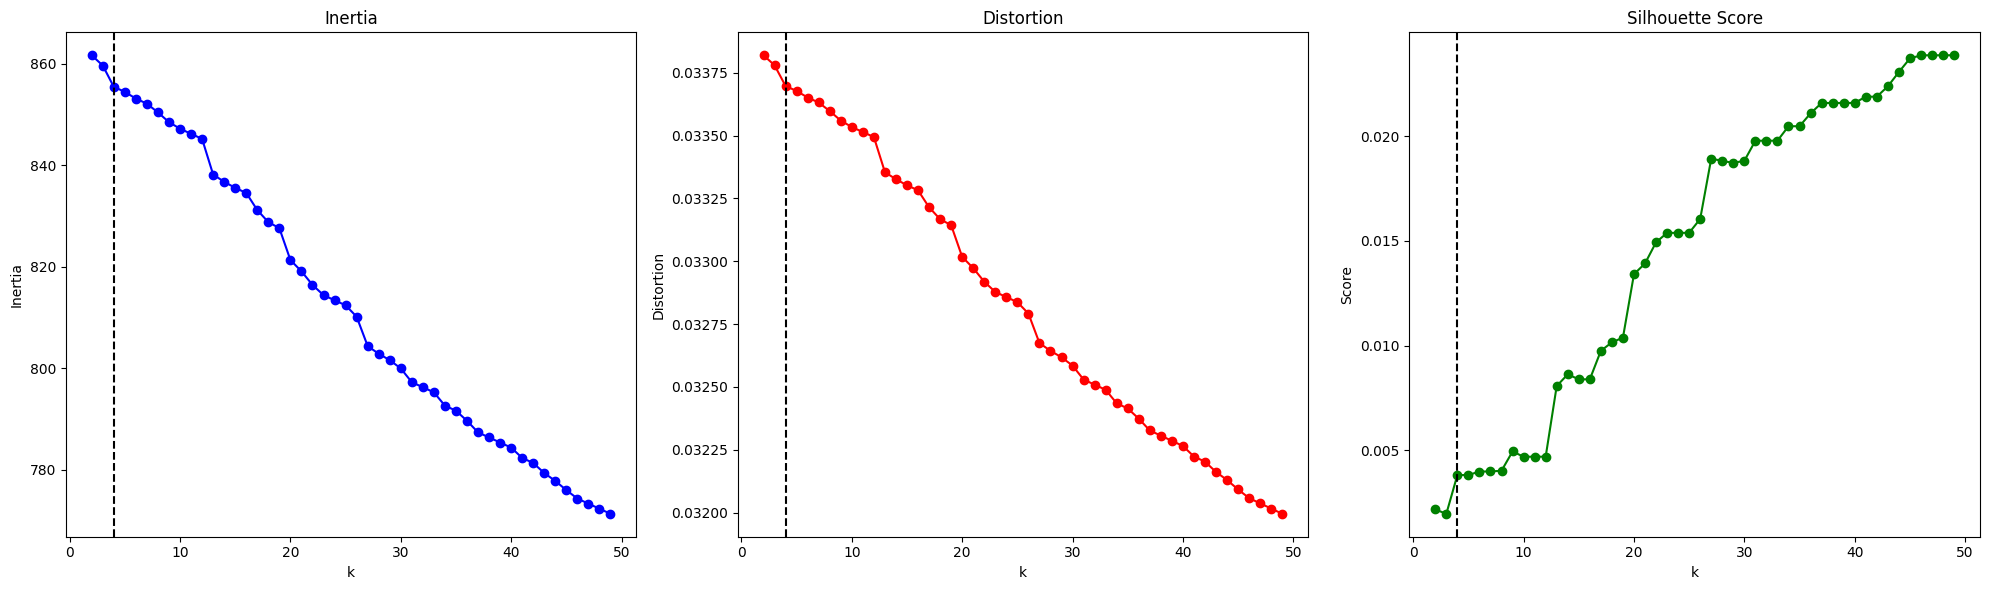

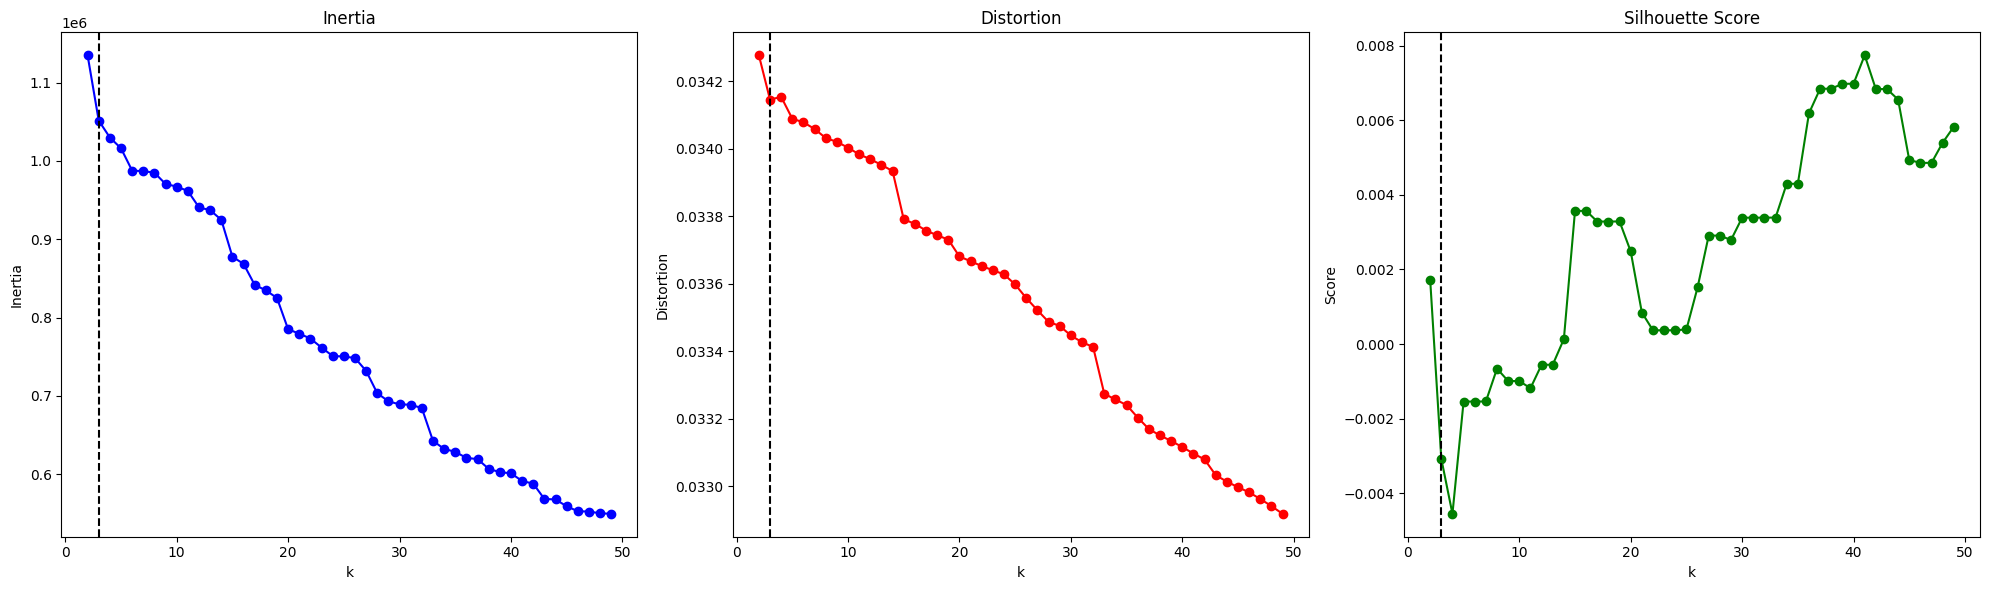

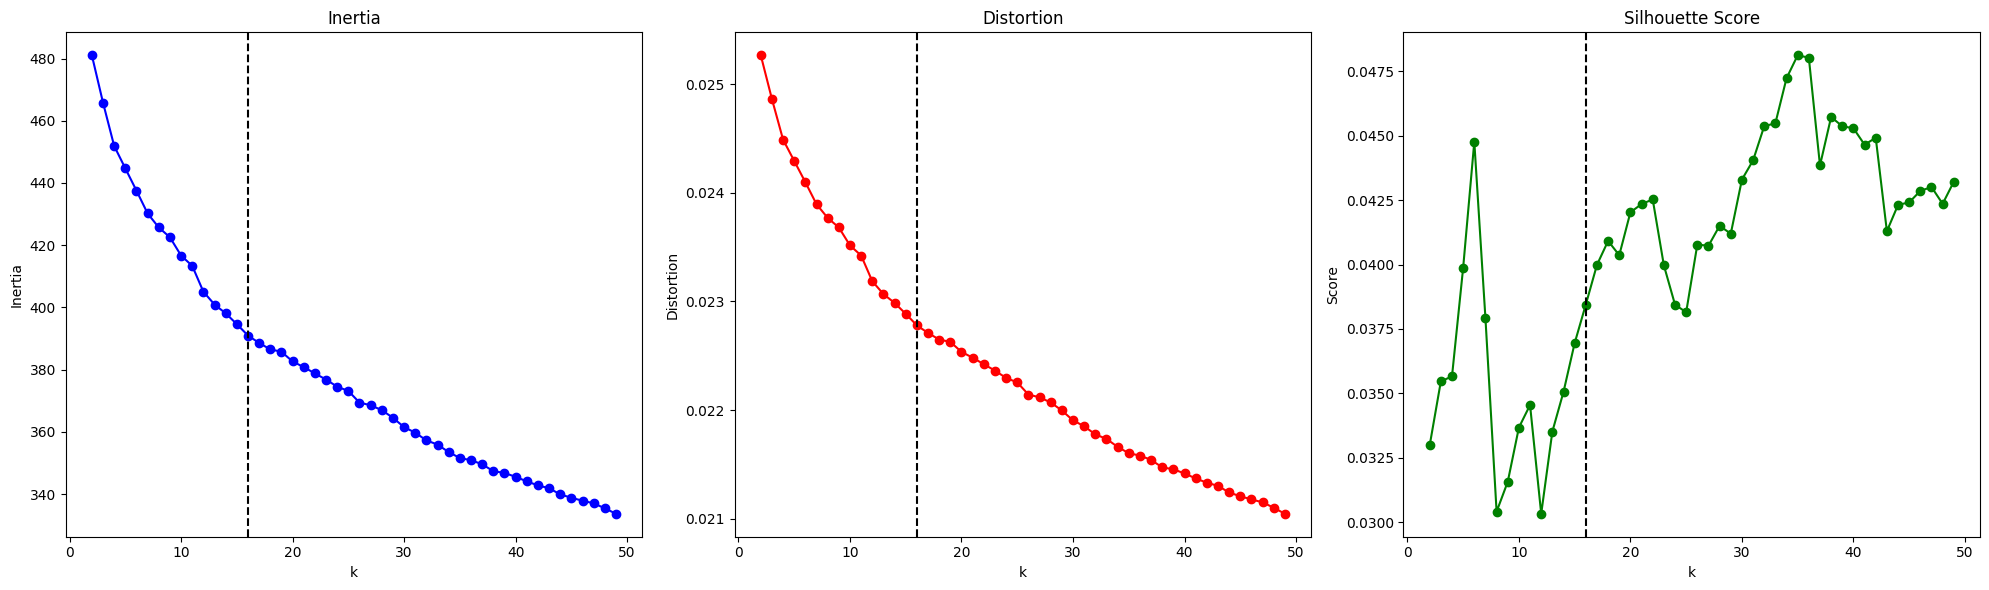

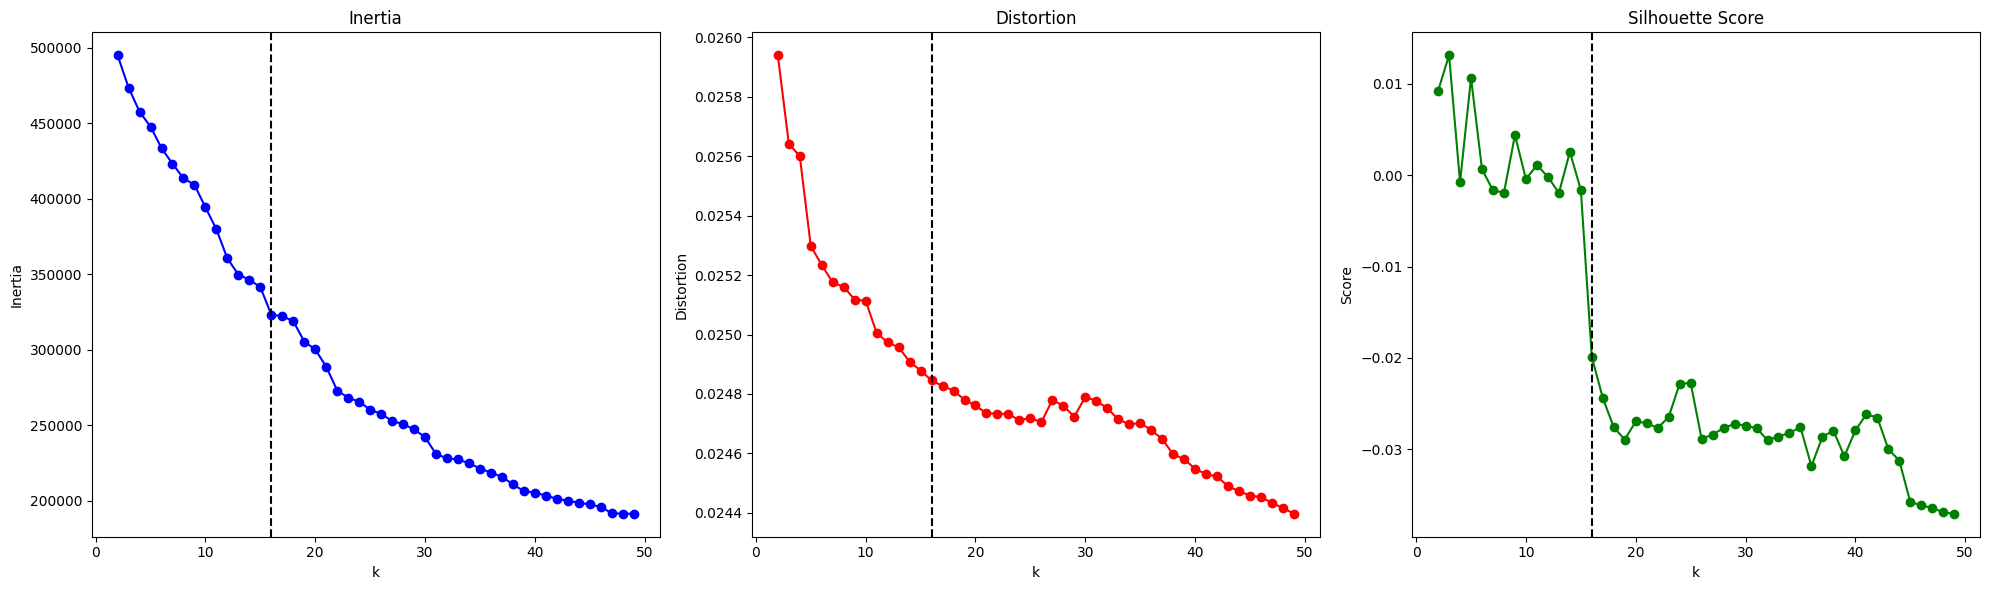

In [73]:
# Optimal number of clusters for unweighted, tf-idf, kmeans model
bk1 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='bkmeans')

# Optimal number of clusters for weighted, tf-idf, kmeans model
bk2 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='bkmeans', weighted=True)

# Optimal number of cluster for unweighted, w2v, kmeans model
bk3 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='bkmeans')

# Optimal number of cluster for weighted, w2v, kmeans model
bk4 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='bkmeans', weighted=True)

In [74]:
# Models 

# Unweighted, tf-idf, kmeans
bm1 = bkmeans_model(n_clusters=bk1, data=e_t)

# Weighted, tf-idf, kmeans
bm2 = bkmeans_model(n_clusters=bk2, data=e_t, weighted=True)

# Unweighted, w2v, kmeans
bm3 = bkmeans_model(n_clusters=bk3, data=e_w)

# Weighted, w2v, kmeans
bm4 = bkmeans_model(n_clusters=bk4, data=e_w, weighted=True)

In [75]:
def remap(reason:str, model, data: np.ndarray) -> int:
    '''
    Input:
        str - the reason of the encounter 
    Output:
        Tuple[int, int] - the corresponding cluster of the unweighted and weighted models respectively
    '''
    idx_of_reason = np.where(reason == unique_reasons)
    return model.predict(data[idx_of_reason])[0]

# remap('ABDOMINAL PAIN', model=model, model_weighted=model_weighted)


In [76]:
unique_vals = df["REASON_VISIT_NAME"].unique()
unique_vals

array(['BREATHING PROBLEM', 'BURN', 'SHAKING', 'VOMITING', 'FROSTBITE',
       'SEIZURES', 'ANXIETY', 'FEVER', 'COPD', 'LACERATION', 'FALL',
       'SYNCOPE', 'ABDOMINAL PAIN', 'NEAR SYNCOPE', 'SHORTNESS OF BREATH',
       'DRUG OVERDOSE', 'URINARY BURNING', 'DERM PROBLEM',
       'NASAL CONGESTION', 'COUGH', 'LEG PAIN', 'SORE THROAT',
       'SURGICAL FOLLOWUP', 'WEAKNESS', 'BACK PAIN', 'FLANK PAIN',
       'FOOT PAIN', 'HEADACHE', 'KNEE PAIN', 'ARM PAIN', 'CELLULITIS',
       'CHEST PAIN', 'EVALUATION OF SEXUAL ASSAULT', 'CLOSED HEAD INJURY',
       'FLU  LIKE SYMPTOMS', 'HAND PAIN', 'NaN', 'NAUSEA',
       'ASSAULT VICTIM', 'COLD EXPOSURE', 'RECTAL PAIN', 'RECTAL PROBLEM',
       'BLOOD PRESSURE', 'EAR INFECTION', 'HEMATEMESIS', 'OTHER',
       'RESPIRATORY DISTRESS', 'ANKLE PAIN', 'FOOT INJURY', 'DIZZINESS',
       'FACIAL INJURY', 'HIGH BLOOD SUGAR', 'MEDICATION REQUEST',
       'MOTOR VEHICLE CRASH', 'SWELLING', 'RASH', 'RIB PAIN',
       'SHOULDER PAIN', 'NECK PAIN', 'DIARRHEA',

In [77]:
# Include the clustering to the df
unique_vals = df["REASON_VISIT_NAME"].unique()

br1 = {val: remap(val, bm1, e_t) for val in unique_vals}
br2 = {val: remap(val, bm2, e_t) for val in unique_vals}
br3 = {val: remap(val, bm3, e_w) for val in unique_vals}
br4 = {val: remap(val, bm4, e_w) for val in unique_vals}

df["bkm_tf-idf"] = df["REASON_VISIT_NAME"].map(br1)
df["bkm_tf-idf_weighted"] = df["REASON_VISIT_NAME"].map(br2)
df["bkm_w2v"] = df["REASON_VISIT_NAME"].map(br3)
df["bkm_w2v_weighted"] = df["REASON_VISIT_NAME"].map(br4)

In [78]:
df

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,td-idf,weighted_td-idf,w2v,w2v_weighted,bkm_tf-idf,bkm_tf-idf_weighted,bkm_w2v,bkm_w2v_weighted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1,3,2,15,0,2,2,5,9
1,A,2018-01-01,0,BURN,1,0,2,2,13,2,3,2,0,3
2,A,2018-01-01,0,SHAKING,1,1,2,2,0,3,3,2,8,13
3,A,2018-01-01,0,VOMITING,1,0,2,2,4,3,3,2,10,14
4,A,2018-01-01,1,FROSTBITE,1,0,2,2,13,2,3,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,7,13,2,3,2,0,3
1174306,D,2025-08-31,23,CHEST PAIN,1,0,4,2,3,5,3,2,15,15
1174307,D,2025-08-31,23,DIZZINESS,1,0,2,2,6,3,3,2,14,14
1174308,D,2025-08-31,23,FINGER PAIN,1,0,2,2,8,5,3,2,13,15


In [79]:
grouped_by_bkm_clusters = df.groupby(by='bkm_tf-idf').agg('size')
grouped_by_bkm_w_clusters = df.groupby(by='bkm_tf-idf_weighted').agg('size')
grouped_by_bkm_w2v_clusters = df.groupby(by='bkm_w2v').agg('size')
grouped_by_bkm_w_w2v_clusters = df.groupby(by='bkm_w2v_weighted').agg('size')


In [80]:
display(grouped_by_bkm_clusters.describe())
display(grouped_by_bkm_w_clusters.describe())
display(grouped_by_bkm_w2v_clusters.describe())
display(grouped_by_bkm_w_w2v_clusters.describe())

count    4.000000e+00
mean     2.935775e+05
std      4.795416e+05
min      5.842000e+03
25%      4.867900e+04
50%      7.884850e+04
75%      3.237470e+05
max      1.010771e+06
dtype: float64

count    3.000000e+00
mean     3.914367e+05
std      5.863198e+05
min      1.153900e+04
25%      5.380550e+04
50%      9.607200e+04
75%      5.813855e+05
max      1.066699e+06
dtype: float64

count        16.000000
mean      73394.375000
std       43580.642424
min       11855.000000
25%       44106.000000
50%       63906.000000
75%       85675.000000
max      178437.000000
dtype: float64

count        16.000000
mean      73394.375000
std       84971.945227
min        1472.000000
25%       20973.750000
50%       50860.000000
75%       78577.000000
max      334539.000000
dtype: float64

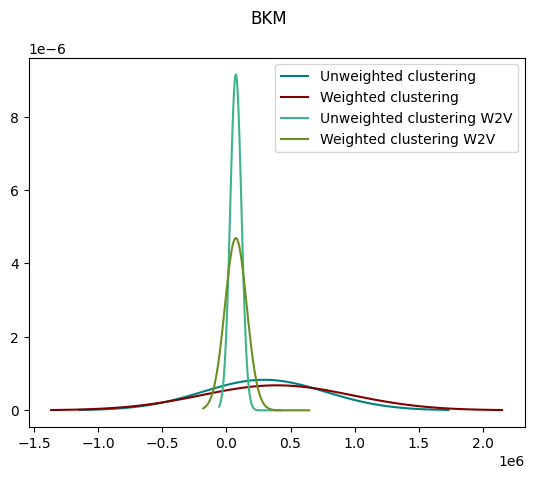

In [81]:
mu1 = grouped_by_bkm_clusters.mean()
sigma1 = grouped_by_bkm_clusters.std()
variance1 = sigma1 ** 2

mu2 = grouped_by_bkm_w_clusters.mean()
sigma2 = grouped_by_bkm_w_clusters.std()
variance2 = sigma2 ** 2

mu3 = grouped_by_bkm_w2v_clusters.mean()
sigma3 = grouped_by_bkm_w2v_clusters.std()
variance1 = sigma3 ** 2

mu4 = grouped_by_bkm_w_w2v_clusters.mean()
sigma4 = grouped_by_bkm_w_w2v_clusters.std()
variance4 = sigma4 ** 2

x1 = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 100)
x2 = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 100)
x3 = np.linspace(mu3 - 3*sigma3, mu1 + 3*sigma3, 100)
x4 = np.linspace(mu4 - 3*sigma4, mu2 + 3*sigma4, 100)

plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Unweighted clustering')
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Weighted clustering')
plt.plot(x3, stats.norm.pdf(x3, mu3, sigma3), label='Unweighted clustering W2V')
plt.plot(x4, stats.norm.pdf(x4, mu4, sigma4), label='Weighted clustering W2V')
plt.suptitle('BKM')
plt.legend()
plt.show()

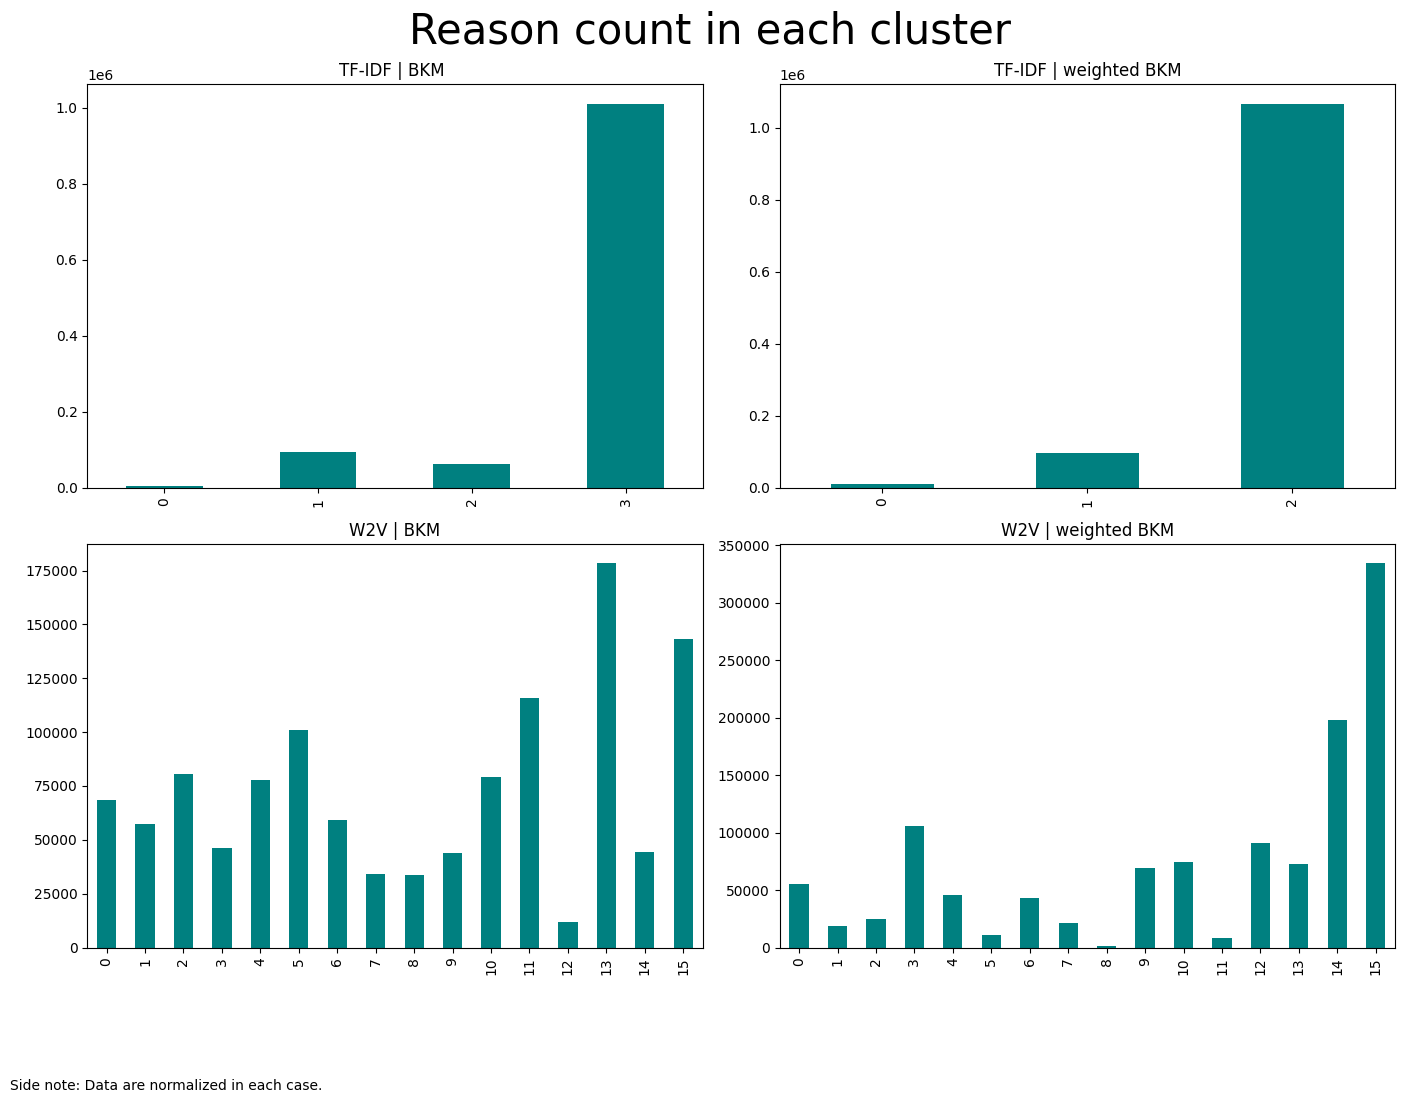

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_bkm_clusters.plot(kind='bar', ax=axes[0,0], title='TF-IDF | BKM ', xlabel='')
grouped_by_bkm_w_clusters.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted BKM', xlabel='')

grouped_by_bkm_w2v_clusters.plot(kind='bar', ax=axes[1,0], title='W2V | BKM', xlabel='')
grouped_by_bkm_w_w2v_clusters.plot(kind='bar', ax=axes[1,1], title='W2V | weighted BKM', xlabel='')

fig.suptitle('Reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')

plt.tight_layout()
plt.show()

In [83]:
grouped_by_bkm_clusters_unique_reasons = df.groupby(by=['bkm_tf-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_clusters_unique_reasons['count'] = grouped_by_bkm_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_clusters_unique_reasons

,REASON_VISIT_NAME,count
bkm_tf-idf,,
0,"[COLD EXPOSURE, EXPOSURE TO STD, BODY FLUID EX...",9
1,[ABDOMINAL PAIN],1
2,"[BREATHING PROBLEM, DERM PROBLEM, RECTAL PROBL...",16
3,"[BURN, SHAKING, VOMITING, FROSTBITE, SEIZURES,...",842


In [84]:
grouped_by_bkm_w_clusters_unique_unique_reasons = df.groupby(by=['bkm_tf-idf_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w_clusters_unique_unique_reasons['count'] = grouped_by_bkm_w_clusters_unique_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w_clusters_unique_unique_reasons

,REASON_VISIT_NAME,count
bkm_tf-idf_weighted,,
0,"[NASAL CONGESTION, FOREIGN BODY IN NOSE, FOREI...",15
1,"[ABDOMINAL PAIN, ABDOMINAL AORTIC ANEURYSM, AB...",6
2,"[BREATHING PROBLEM, BURN, SHAKING, VOMITING, F...",847


In [85]:
grouped_by_bkm_w2v_clusters_unique_reasons = df.groupby(by=['bkm_w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w2v_clusters_unique_reasons['count'] = grouped_by_bkm_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
bkm_w2v,,
0,"[BURN, FROSTBITE, FOOT INJURY, FACIAL INJURY, ...",55
1,"[SEIZURES, SYNCOPE, NEAR SYNCOPE, HYPOTHERMIA,...",31
2,"[LACERATION, DRUG OVERDOSE, CLOSED HEAD INJURY...",27
3,[FALL],1
4,"[COPD, EVALUATION OF SEXUAL ASSAULT, FLU LIKE...",122
5,"[BREATHING PROBLEM, DERM PROBLEM, RECTAL PROBL...",121
6,"[URINARY BURNING, BLOOD PRESSURE, HIGH BLOOD S...",163
7,"[SURGICAL FOLLOWUP, CELLULITIS, EAR INFECTION,...",124
8,"[SHAKING, NASAL CONGESTION, NaN, EPISTAXIS, UN...",110


In [86]:
grouped_by_bkm_w_w2v_clusters_unique_reasons = df.groupby(by=['bkm_w2v_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w_w2v_clusters_unique_reasons['count'] = grouped_by_bkm_w_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
bkm_w2v_weighted,,
0,"[NASAL CONGESTION, SORE THROAT, SURGICAL FOLLO...",58
1,"[COLD EXPOSURE, ANIMAL BITE, FOREIGN BODY IN N...",44
2,"[URINARY BURNING, EAR INFECTION, ABSCESS, VAGI...",63
3,"[BURN, FROSTBITE, LACERATION, CLOSED HEAD INJU...",63
4,"[FEVER, DIARRHEA, APPENDICITIS, UTI, CROUP, HE...",43
5,"[COPD, ALLERGIC REACTION, ANGIOEDEMA, ASTHMA, ...",43
6,"[NaN, HYPOTHERMIA, HYPERTENSION, UNRESPONSIVE,...",74
7,"[HEMATEMESIS, URINARY RETENTION, URINARY FREQU...",52
8,"[MISCARRIAGE, METRORRHAGIA, BREAST MASS, BREAS...",51


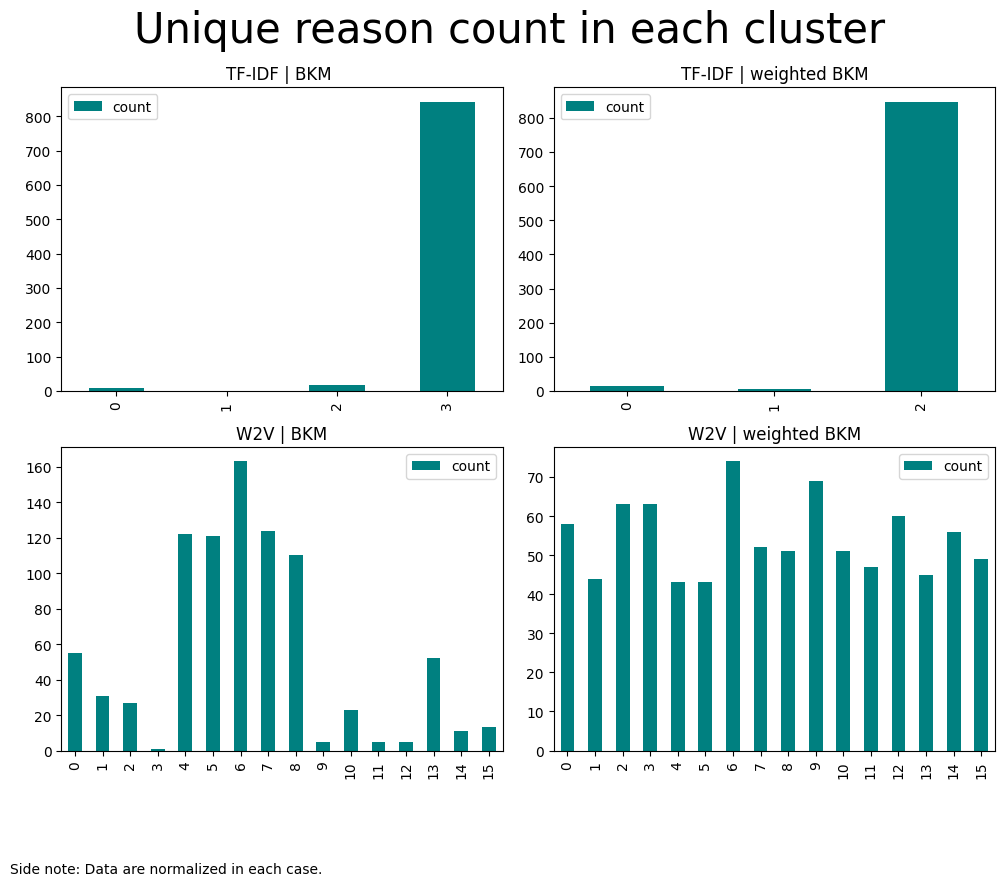

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

grouped_by_bkm_clusters_unique_reasons.plot(kind='bar', ax=axes[0,0], title='TF-IDF | BKM ', xlabel='')
grouped_by_bkm_w_clusters_unique_unique_reasons.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted BKM', xlabel='')

grouped_by_bkm_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,0], title='W2V | BKM', xlabel='')
grouped_by_bkm_w_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,1], title='W2V | weighted BKM', xlabel='')

fig.suptitle('Unique reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()


Even though the similarity with the kmeans-w2v unweighted model in the bottom right bar plot is clear, and we can grow some confidence that our models actually understand the semantics of the dataset, we should perform more analysis, since barplots only contain sizes. We may have the same sizes of clusters but different members in them (although that sounds unlike).

In [88]:
grouped_by_bkm_w_w2v_clusters_unique_reasons.to_csv('test.csv')


## Evaluation

### Davies Boulding scores

[Geeksforgeeks: DBI](https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/)

**Davies-Bouldin Index:** a metric for evaluating clustering quality, measuring the average similarity between clusters. The lower the better

Advantages of the Davies-Bouldin Index

*    The DBI is a relative metric, which means that it can be used to compare the clustering results of different algorithms on the same dataset.
*    The DBI has a clear interpretation: a lower DBI value indicates more compact and well-separated clusters.
*    It is a relatively simple metric to calculate.
*    It provides a global measure of the quality of a clustering solution.
*    It is relatively insensitive to the choice of distance metric.

Limitations of the Davies-Bouldin Index

*    The Davies-Bouldin Index is sensitive to outliers and noise in the data.
*    The Davies-Bouldin Index does not take into account the structure or distribution of data, such as clusters within clusters or non-linear relationships.
*    The Davies-Bouldin Index only considers the pairwise distances between cluster centroids and cluster members.
*    The DBI can be computationally expensive to calculate for large datasets.
*    The DBI is not suitable for all clustering tasks. For example, it is not well-suited for clustering tasks where the clusters are not well-separated.

In [89]:
db_km_1 = davies_bouldin_score(e_t, m1.labels_)
db_km_2 = davies_bouldin_score(e_t, m2.labels_)
db_km_3 = davies_bouldin_score(e_w, m3.labels_)
db_km_4 = davies_bouldin_score(e_w, m4.labels_)

db_km_1, db_km_2, db_km_3, db_km_4

(1.6534151502536851, 3.3544192495057277, 3.1475914551999162, 3.634841308623461)

In [90]:
db_bkm_1 = davies_bouldin_score(e_t, bm1.labels_)
db_bkm_2 = davies_bouldin_score(e_t, bm2.labels_)
db_bkm_3 = davies_bouldin_score(e_w, bm3.labels_)
db_bkm_4 = davies_bouldin_score(e_w, bm4.labels_)

db_bkm_1, db_bkm_2, db_bkm_3, db_bkm_4

(3.311593572179846, 3.612987459222158, 3.6651367864750815, 3.6905196975675167)

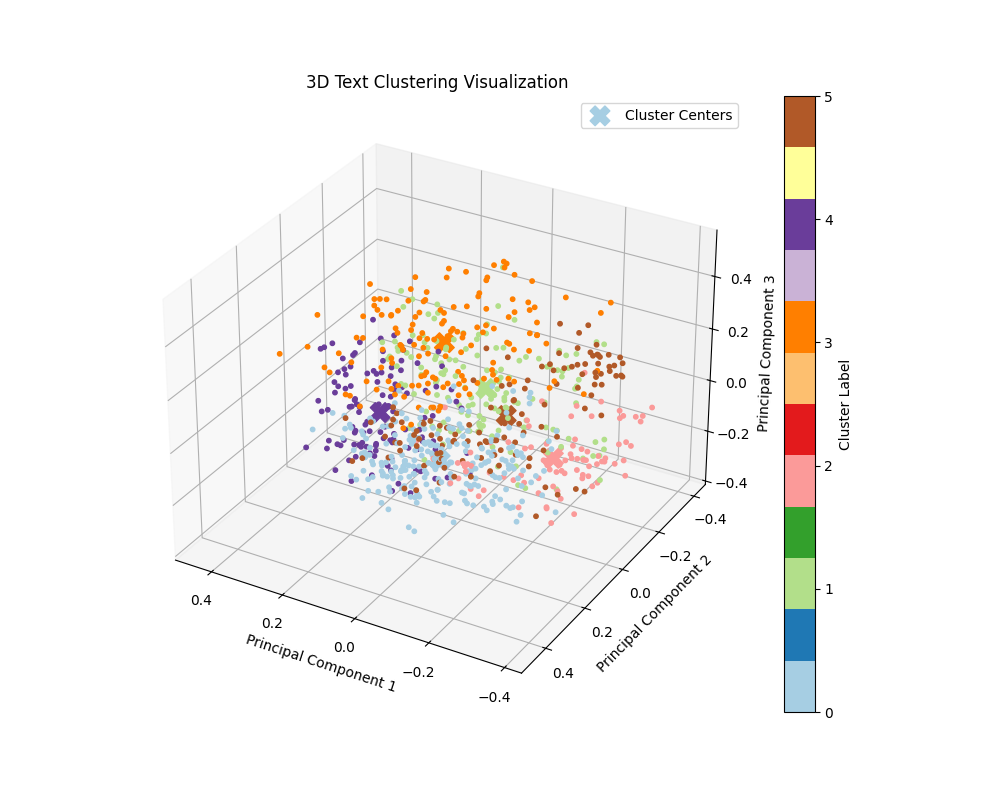

In [91]:
%matplotlib widget
import matplotlib.pyplot as plt


pca = PCA(n_components=3)
X_reduced = pca.fit_transform(e_w)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=m4.labels_,
    cmap='Paired',
    s=10,
    alpha=1
)

ax.set_title("3D Text Clustering Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

# --- cluster centers ---
centers = m4.cluster_centers_
centers_reduced = pca.transform(centers)

ax.scatter(
    centers_reduced[:, 0],
    centers_reduced[:, 1],
    centers_reduced[:, 2],
    c=np.unique(m4.labels_),
    cmap='Paired',
    s=200,
    marker='X',
    alpha=1,
    label='Cluster Centers'
)

ax.legend()
fig.colorbar(scatter, ax=ax, label='Cluster Label')
ax.view_init(elev=30, azim=120)

plt.show()

In [92]:
%matplotlib inline

In [93]:
df

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,td-idf,weighted_td-idf,w2v,w2v_weighted,bkm_tf-idf,bkm_tf-idf_weighted,bkm_w2v,bkm_w2v_weighted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1,3,2,15,0,2,2,5,9
1,A,2018-01-01,0,BURN,1,0,2,2,13,2,3,2,0,3
2,A,2018-01-01,0,SHAKING,1,1,2,2,0,3,3,2,8,13
3,A,2018-01-01,0,VOMITING,1,0,2,2,4,3,3,2,10,14
4,A,2018-01-01,1,FROSTBITE,1,0,2,2,13,2,3,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,7,13,2,3,2,0,3
1174306,D,2025-08-31,23,CHEST PAIN,1,0,4,2,3,5,3,2,15,15
1174307,D,2025-08-31,23,DIZZINESS,1,0,2,2,6,3,3,2,14,14
1174308,D,2025-08-31,23,FINGER PAIN,1,0,2,2,8,5,3,2,13,15


# Ways to move forward ? 

* Important: Decide on a forecasting model and start building it. Ideas?

* Try different embedding models.

* Should we trust the clusters and do analytics using them ?

In [110]:
grouped_by_cluster_df = df.groupby(by='bkm_w2v_weighted').agg(
    total_enc=('ED Enc', 'sum'),
    total_adm=('ED Enc Admitted', 'sum')
)
grouped_by_cluster_df['admission_rate'] = grouped_by_cluster_df['total_adm'] / grouped_by_cluster_df['total_enc']

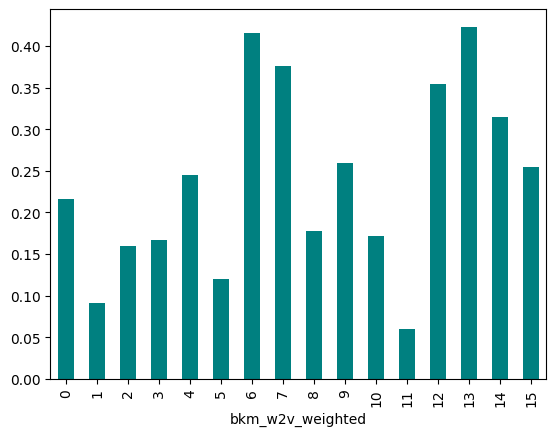

In [111]:
grouped_by_cluster_df['admission_rate'].plot(kind='bar')
plt.show()

# Perhaps partition the clusters by importance given some threshold for each category.